<h1 align="center">SWDB Problem Set: Becoming a Data Detective</h1>
<h3 align="center">From someone else's figure to your own analysis</h3>
<p align="center"><b>SOLUTIONS</b> &mdash; worked on the Dynamic Routing dataset (Neuropixels)</p>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>How this problem set works</h2>

In the today's tutorial you explored a dataset and made figures. Those figures are now posted on Slack.

**Your starting point is one of your classmates' figures.** Pick any figure from the channel, along
with the dataset it came from &mdash; ideally one you did *not* work on this morning.

The task for this problem set is to reproduce your classmate's figure, then dive deeper into the dataset 
to investigate what conditions are available, explore activity patterns across trials and across cells,
and consider how your analysis decisions affect your interpretation of the data. 

| Part | Task |
| --- | --- |
| 1 | Load their dataset and find the pieces the figure needs |
| 2 | Reproduce the figure, and interrogate what it shows |
| 3 | Align activity to event onsets: raster and PSTH |
| 4 | Signal and noise correlations, and whether to trust them |

You already have the data-access skills for Part 1 from this morning's tutorial. This problem set is
about what comes after loading: **shaping data, and checking whether the result means anything.**

**Deliverable:** a short README naming the figure and dataset you chose, the decisions you made at
each step, and an honest assessment of what your numbers do and do not support.

<b>Every dataset is different, and the notebook does not know which one you picked.</b> The code
cells are prompts, not templates &mdash; you write what goes in them, using the access patterns from
this morning. Only a few things are given: the imports, and two helper functions from the tutorial.

There are several important differences to look out for across the datasets in this workshop:

- **Recording modality** &mdash; a continuous calcium signal in some, discrete spike times in
  others. Spikes need binning before anything here applies.
- **Sampling rate** &mdash; from a few Hz to tens of kHz, which determines what timing you can resolve.
- **Number of neurons** &mdash; tens to thousands, which changes what is tractable in your analysis.
- **Stimulus structure** &mdash; many conditions with few repeats, few conditions with many, or no
  sensory stimulus at all.
- **What was recorded alongside** &mdash; running, licking, pupil, reward; some datasets have all of
  it, some none.
- **Where things live in the file** &mdash; container and column names differ, and so does which
  container holds the stimulus or trials table.

None of that is written on the outside of the file. **You have to look.** Part of each prompt is
deciding whether the analysis it asks for even applies to your dataset &mdash; and saying so when it
does not.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h2>Taking it slow: Analysis step by step</h2>

In the age of LLMs, you can now generate an analysis faster than you can check one. Ask an LLM for a correlation matrix
and you will have one in thirty seconds, beautifully formatted, with a colorbar.

The problem is that a result computed on four trials can look exactly like a result computed on four
hundred. A bug can look exactly like a finding. A correlation computed in a window where nothing
happened can look exactly like a real effect.

This is also true of analyses performed by other humans, such as figures in a paper, or the plot generated by your colleague in today's tutorial. 
To truly understand any given result, you need to consider the essential features of the data, 
how it was transformed, how it is being displayed, and the assumptions that were made. 
This is important to consider as you work through your own analysis as well. 

So the questions to keep asking are:

- **What is actually in this data file?** Not what you assume &mdash; what is there.
- **Does this dataset support the question I am asking?** 
- **How is the data being transformed?** Plot the data after each step.
- **What would make this result wrong?** Name it before you see the answer.

</div>

---

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pynwb
from scipy import stats

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

data_dir = '/data'

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 1: Load the dataset and find the pieces you need</h1>

Same access pattern as this morning: find your dataset's mount under <code>/data</code>, locate a
session's NWB file, then dot and bracket notation into the containers.

**Your classmate's figure tells you what to look for.** Before you open anything, list the pieces the
figure needs &mdash; neural activity, plus whatever else it plots: a behavioral trace, epoch
boundaries, trial times, stimulus identity.

</div>

In [2]:
# List the datasets mounted under /data.

for mount in sorted(os.listdir(data_dir)):
    print(mount)

409828_V1DD_Filtered
416296_V1DD_Filtered
427836_V1DD_Filtered
438833_V1DD_Filtered
Neuropixels_Opto_ecephys_nwb_combined
Visual-Learning-SWDB
brain-computer-interface-v2
dynamicrouting_datacube
metadata
visual_coding_neuropixels
visual_coding_ophys


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Which session does your classmate's figure come from? Use the table to find it
&mdash; subject, session type, date &mdash; and say what you filtered on.

Look at what the table offers before you filter. How many subjects, how many session types, how many
sessions each? That inventory is the first thing you know about the dataset.

**What are the features of your selected sesssion?** Is it from a specific recording location or does it utilize a particular stimulus set?

Ask what kind of neurons you are recording from in the selected session. This is not a detail &mdash; it decides
what your population average means. Check the transgenic line, the virus, and any other metadata
describing what was labeled. 

The recording modality also has important implications: 

- **Imaging.** You see only the cells expressing the calcium indicator. A pan-excitatory driver
  gives you a very different population from an interneuron-specific one, and "population activity"
  in each case means something different.
- **Electrophysiology.** A probe records whatever is near it, so the recording is not cell-type
  specific by default. But a line or virus may still be present for **optotagging** &mdash; light
  activation used to identify a targeted cell type among the recorded units. If so, there may be a
  column marking which units were tagged.

Write down what is labeled and recorded in your session, and say what population your averages are actually
averaging over. 

</div>

In [3]:
# read your dataset's metadata CSV from /code/metadata and look at what it
# offers: how many subjects, how many session types, how many sessions each.

metadata = pd.read_csv(os.path.join(data_dir, 'metadata', 'dynamic_routing_metadata.csv'))

print('shape of metadata table:', metadata.shape)
print('columns in metadata table:', metadata.columns.tolist())

metadata.head()

shape of metadata table: (12, 19)
columns in metadata table: ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex', 'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure', 'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL', 'mean_dprime_same_modal', 'mean_dprime_other_modal']


,project_name,_id,name,subject_id,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,targeted_structure,trials_total,trials_rewarded,reward_rate,reward_consumed_mL,mean_dprime_same_modal,mean_dprime_other_modal
0,Dynamic Routing,897335f6-895c-455e-89c4-667d86a4304e,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,243,Female,"['Extracellular electrophysiology', 'Behavior'...",2023-08-24,14:28:28,16:28:14.588745,['Piriform area' 'root'],476,123,0.258403,3.84,2.152875,2.209537
1,Dynamic Routing,c4ec72da-c795-4da8-a498-3531a621ddc0,ecephys_664851_2023-11-16_12-54-53_nwb_2026-08...,664851,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-01-09,311,Female,"['Extracellular electrophysiology', 'Behavior'...",2023-11-16,12:54:53,14:46:25.481437,['Secondary motor area' 'Field CA1' 'Subiculum...,527,139,0.263757,4.35,3.133879,2.593231
2,Dynamic Routing,678d3a97-d1f2-4533-a7e0-1300fed47cfb,ecephys_667252_2023-09-28_15-00-38_nwb_2026-08...,667252,wt/wt,2023-01-27,244,Female,"['Extracellular electrophysiology', 'Behavior'...",2023-09-28,15:00:38,17:03:03.333877,['Secondary motor area' 'Primary motor area' '...,486,123,0.253086,3.78,3.261005,2.260717
3,Dynamic Routing,ffa07448-b91d-4bdf-b3ab-9e6f2c5a8b4d,ecephys_708016_2024-04-29_12-59-12_nwb_2026-08...,708016,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-10-18,194,Male,"['Extracellular electrophysiology', 'Behavior'...",2024-04-29,12:59:12,15:00:31.755703,['Secondary motor area' 'Primary somatosensory...,533,129,0.242026,4.05,3.027970,2.665116
4,Dynamic Routing,9deb4162-9e9b-4ee7-b5e4-db804fd4fcd5,ecephys_712815_2024-05-22_12-26-32_nwb_2026-08...,712815,wt/wt,2023-11-17,187,Female,"['Extracellular electrophysiology', 'Behavior'...",2024-05-22,12:26:32,14:23:25.111009,['Dentate gyrus' 'Posterior complex of the tha...,545,138,0.253211,4.17,2.988601,1.745163


In [4]:
# Inventory the metadata table - how many subjects, sessions, session_types
# There is no session_type column here: one row per subject, one session each.
# What this table DOES carry is behavior -- trial counts and d-prime -- so the
# session is characterized by how well the mouse performed, not by a label.
print('sessions:', len(metadata), '| subjects:', metadata.subject_id.nunique())
print()
metadata[['subject_id', 'genotype', 'sex', 'age', 'trials_total',
          'trials_rewarded', 'mean_dprime_same_modal', 'mean_dprime_other_modal']]

sessions: 12 | subjects: 12



,subject_id,genotype,sex,age,trials_total,trials_rewarded,mean_dprime_same_modal,mean_dprime_other_modal
0,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,Female,243,476,123,2.152875,2.209537
1,664851,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,Female,311,527,139,3.133879,2.593231
2,667252,wt/wt,Female,244,486,123,3.261005,2.260717
3,708016,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,Male,194,533,129,3.027970,2.665116
4,712815,wt/wt,Female,187,545,138,2.988601,1.745163
5,713655,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,Male,260,515,129,2.841083,3.002527
6,714748,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,Male,206,550,134,3.329563,2.693473
7,715710,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,Male,222,548,131,2.032598,1.928238
8,741137,wt/wt,Male,205,543,124,3.113432,2.623589
9,742903,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,Female,160,489,124,3.177007,2.342171


In [5]:
# Filter the table to the session behind your figure, take one row as
# `session`, and say what you filtered on.
# Which columns identify a session in your dataset -- subject, session type, date?

# WHAT WE FILTER ON: subject_id. Each subject appears once, so this picks a
# session outright. There is no session_type to filter on, and `targeted_structure`
# records the PLANNED probe target -- not what the probe actually passed through --
# so it cannot tell you which areas the recording contains. Only the units table
# inside the file can, which is why the area selection happens later.
subject_id = 664851
candidates = metadata[metadata.subject_id == subject_id]
print(f'subject {subject_id}: {len(candidates)} session(s)')

session = candidates.iloc[0]
print('selected:', session['name'])

subject 664851: 1 session(s)
selected: ecephys_664851_2023-11-16_12-54-53_nwb_2026-08-04_15-09-33


In [6]:
# examine the column values of the session you selected
# what is the session type, genotype, the targeted structure, etc.

# Read `targeted_structure` as intent, not outcome: it lists where the probes were
# AIMED. A Neuropixels shank crosses many structures on its way down, so the
# recording routinely contains areas that appear nowhere in this column.
session

project_name                                                 Dynamic Routing
_id                                     c4ec72da-c795-4da8-a498-3531a621ddc0
name                       ecephys_664851_2023-11-16_12-54-53_nwb_2026-08...
subject_id                                                            664851
genotype                     Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
date_of_birth                                                     2023-01-09
age                                                                      311
sex                                                                   Female
modality                   ['Extracellular electrophysiology', 'Behavior'...
session_date                                                      2023-11-16
session_start_time                                                  12:54:53
session_end_time                                             14:46:25.481437
targeted_structure         ['Secondary motor area' 'Field CA1' 'Subiculum...

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

<b>Now build the path and load the data.</b> The metadata table's <code>name</code> column is normally the session's
folder name inside the mount - identify the relevant asset from the list above and grab the relevant folder from within it. 
Inside that folder sits one NWB store &mdash; either a single <code>.nwb</code> file (HDF5) or a <i>directory</i>
(zarr).

</div>


In [7]:
# set `dataset_dir` to the mount holding your dataset (one of the names
# printed above), then join it with your session's folder name to get `session_dir`.

dataset_dir = os.path.join(data_dir, 'dynamicrouting_datacube')
session_dir = os.path.join(dataset_dir, session['name'])
print(session_dir)

# One session directory holds one NWB store. Match on 'nwb' in the name to catch
# both forms -- a .nwb file and a zarr directory -- but exclude the sidecar
# 'nwb_contents.json' that ships next to the store.
nwb_file = [path for path in os.listdir(session_dir)
            if 'nwb' in path and not path.endswith('.json')]
print(len(nwb_file), 'nwb store(s) detected:', nwb_file)

assert len(nwb_file) == 1, f'expected one NWB store, found {len(nwb_file)}'
nwb_path = os.path.join(session_dir, nwb_file[0])

/data/dynamicrouting_datacube/ecephys_664851_2023-11-16_12-54-53_nwb_2026-08-04_15-09-33
1 nwb store(s) detected: ['664851_2023-11-16.nwb.zarr']


In [8]:
# Open the NWB file. Name it `nwb`.
nwb = pynwb.read_nwb(nwb_path)

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1638: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (400638, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1638: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (400680, 500) float32 read-only>
  warnings.warn(


In [9]:
# Check the metadata within the NWB file. Does it match the session metadata?
# What kind of neurons are labeled? Look for the genotype, and for imaging, the
# imaging plane's indicator.

print('subject :', nwb.subject.subject_id)
print('genotype:', nwb.subject.genotype)
print('species :', nwb.subject.species, '| sex:', nwb.subject.sex)
print('sorted units:', len(nwb.units))

# This is a Neuropixels recording, so there is no indicator and no cell-type
# specificity: the probe records whatever neuron sits near a contact. A
# population average here averages over every sortable neuron in the area.

subject : 664851
genotype: Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt
species : Mus musculus | sex: F
sorted units: 2210


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Find the data the figure needs</h3>

A handful of containers within the NWB file hold almost everything. Which one holds what **varies by dataset**, so list
them all before you index into any of them.

| container | commonly holds |
| --- | --- |
| `processing` | processed neural activity &mdash; in some datasets also behavior |
| `intervals` | epoch tables, trial tables, stimulus presentation tables |
| `stimulus` | stimulus templates &mdash; but in some datasets, the trial tables too |
| `acquisition` | raw acquired signals |
| `events` | discrete behavioral and stimulus events, in some datasets |

<div>


</div>


In [10]:
# What is in this file? Print the container contents -
# processing, intervals, acquisition, stimulus, events.
# Which have entries and which dont?
print('processing :', list(nwb.processing.keys()))
print('intervals  :', list(nwb.intervals.keys()) if nwb.intervals else [])
print('acquisition:', list(nwb.acquisition.keys()))
print('stimulus   :', list(nwb.stimulus.keys()) if nwb.stimulus else [])
print('events     :', list(nwb.events.keys()) if nwb.events else [])

processing : ['behavior', 'ecephys']
intervals  : ['aud_rf_mapping_trials', 'epochs', 'optotagging_trials', 'performance', 'trials', 'vis_rf_mapping_trials']
acquisition: ['frametimes_eye_camera', 'frametimes_front_camera', 'frametimes_side_camera', 'manipulator_positions']
stimulus   : []
events     : []


In [11]:
# What tables are present in each container? What are the columns of those tables?

# Every table in `intervals`, with its shape and columns.
for table_name in (nwb.intervals or {}):
    table = nwb.intervals[table_name].to_dataframe()
    print(f'intervals[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()

intervals['aud_rf_mapping_trials']: (432, 9)
    ['start_time', 'stop_time', 'stim_start_time', 'stim_stop_time', 'trial_index', 'is_AM_noise', 'is_white_noise', 'is_pure_tone', 'freq']

intervals['epochs']: (7, 6)
    ['start_time', 'stop_time', 'script_name', 'notes', 'interval_names', 'tags']

intervals['optotagging_trials']: (200, 16)
    ['start_time', 'stop_time', 'trial_index', 'stim_start_time', 'stim_stop_time', 'baseline_start_time', 'baseline_stop_time', 'response_start_time', 'response_stop_time', 'stim_name', 'nominal_duration', 'location', 'bregma_x', 'bregma_y', 'power', 'wavelength']

intervals['performance']: (6, 20)
    ['start_time', 'stop_time', 'block_index', 'n_trials', 'n_responses', 'n_hits', 'n_contingent_rewards', 'hit_rate', 'false_alarm_rate', 'catch_response_rate', 'rewarded_modality', 'is_first_block_aud', 'cross_modality_dprime', 'signed_cross_modality_dprime', 'vis_dprime', 'aud_dprime', 'vis_target_response_rate', 'vis_nontarget_response_rate', 'aud_tar

In [12]:
# Every table in `stimulus`, with its shape and columns.
for table_name in (nwb.stimulus or {}):
    table = nwb.stimulus[table_name].to_dataframe()
    print(f'stimulus[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()

In [13]:
# Every table in `events`, with its shape and columns.
for table_name in (nwb.events or {}):
    table = nwb.events[table_name].to_dataframe()
    print(f'events[{table_name!r}]: {table.shape}')
    print('   ', list(table.columns))
    print()

In [14]:
# What are the event types?
# Substitute the name of the events table your dataset actually has.

# This file has no `events` container at all. The discrete behavioral events it
# does have -- licks, rewards -- live in processing['behavior'] instead.
list(nwb.processing['behavior'].data_interfaces)

['facemap_front_camera',
 'facemap_side_camera',
 'running_speed',
 'dlc_eye_camera',
 'eye_tracking',
 'licks',
 'lp_front_camera',
 'lp_side_camera',
 'quiescent_interval_violations',
 'rewards']

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Extract neural activity. Do you have ephys units or ophys ROIs? 
Are there multiple activity types (e.g. dFF and deconvolved events) or just one? 
What do the timestamps look like? Is there more than one set of timestamps (e.g. one per plane)?

</div>

In [15]:
# The processing module is itself a container - what containers are in processing?
# This is where processed data associated with neural activity or behavior live
for module_name in nwb.processing:
    print(f'{module_name}:', list(nwb.processing[module_name].data_interfaces.keys()))

behavior: ['facemap_front_camera', 'facemap_side_camera', 'running_speed', 'dlc_eye_camera', 'eye_tracking', 'licks', 'lp_front_camera', 'lp_side_camera', 'quiescent_interval_violations', 'rewards']
ecephys: []


In [16]:
# What is available in each neural activity related container within processing?
# This is where the different representations of the neural signal live (raw, dff, events, ...).
# Pick one container and list what it holds.

print('ecephys :', list(nwb.processing['ecephys'].data_interfaces))
print('behavior:', list(nwb.processing['behavior'].data_interfaces))

ecephys : []
behavior: ['facemap_front_camera', 'facemap_side_camera', 'running_speed', 'dlc_eye_camera', 'eye_tracking', 'licks', 'lp_front_camera', 'lp_side_camera', 'quiescent_interval_violations', 'rewards']


In [17]:
# Does your dataset offer more than one representation of the neural activity
# for this plane or probe? List what is available.

# Spike times are the only representation of neural activity in this file: no
# continuous trace, no deconvolved estimate. They sit on the units table, one
# array of times per unit.
print('columns on the units table:', len(nwb.units.colnames))
print('spike_times present:', 'spike_times' in nwb.units.colnames)

columns on the units table: 59
spike_times present: True


In [18]:
# Find the neural activity in this file and extract the relevant data
# How is it formatted? What other information is available about cell activity?
# If your dataset has multiple planes or probes, start with one.

units = nwb.units.to_dataframe()
print('units table:', units.shape)

# Which areas were recorded? Labels vary between sessions ('VISp' in one,
# 'VISp2/3' in another), so look before choosing rather than copying a list.
print(units.structure.astype(str).value_counts().head(10).to_string())

units table: (2210, 59)
structure
MOs     360
PL      329
ORBm    247
ACAd    183
SUB     158
CA1     132
FRP     112
VISp    104
MOB      99
LP       65


In [19]:
# Load the second representation (deconvolved events, spike estimates).
# Does it share the first one's shape and timestamps? What fraction of it is
# exactly zero, and why might that be?

# There is no second representation here. Spike times are the raw currency of a
# sorted probe recording -- everything else in this notebook is built from them,
# and the binning choice below is what a "representation" means for this dataset.
# The comparison this prompt asks for is made across two BIN WIDTHS in Part 3.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Is your dataset continuous or spiking?</b> This is the first fork in the road, and it
changes what "activity" even means.

<b>Continuous</b> (calcium imaging, LFP): represented as a `(n_timepoints, n_cells)` array, with values for every timepoint. Find it and you are done.

<b>Spiking</b> (Neuropixels, sorted electrophysiology): Each unit carries its
own list of spike times, usually in a `units` table. If your analysis requires a continuous spike rate, 
you must <b>bin</b> the spike times yourself &mdash;
choose a bin width, count spikes per bin, divide by the width to get a rate in spikes/s. 

Two decisions come with spiking data, and neither has a default:

- <b>Which units.</b> Spike sorting produces more units than you should analyze. There will be
  quality-control columns (`is_qc_pass`, `firing_rate`, `presence_ratio`, `snr`) and often an
  anatomical label. Select on them explicitly and say what you selected &mdash; a session can drop
  from thousands of units to dozens, and the ones you drop change your answer.
- <b>Bin width.</b> Too wide blurs the response; too narrow leaves mostly-empty bins and noisy
  single-trial estimates. Try a few and see how much your answer moves.

<pre>
bin_width = 0.010                                    # seconds -- your decision
edges = np.arange(0, t_end + bin_width, bin_width)
counts, _ = np.histogram(one_unit_spike_times, bins=edges)
rate = counts / bin_width                            # spikes/s
bin_centers = edges[:-1] + bin_width / 2
</pre>

Sparse binned spikes behave like a deconvolved calcium trace: sharper in time, and noisy per
trial.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Other things to consider.</b>

<b>Lazy loading.</b> NWB data objects do not load until you index them. That is what lets you open a
50&nbsp;GB file instantly, but it means `data.std()` may fail where `np.std(data)` works. Convert
with `np.asarray()` once you know the array is small enough to hold, or slice first.

<b>Timestamps.</b> Some datasets store an explicit `timestamps` array; others store a sampling
`rate` and a `starting_time`, and you reconstruct the times yourself. Everything downstream needs
real times in seconds, so check which you have &mdash; `series.timestamps` is `None` when the file
uses a rate.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Get the timestamps for your neural signal. What is the acquisition rate? 

If there are multiple imaging planes, check whether they all have the same timestamps.

</div>

In [20]:
# Where are the timestamps located? What is the acquisition rate?
# Note that some datasets store a rate instead of a timestamps array.

# Neither: a spiking dataset has no sampled trace, so there is no timestamps
# array and no acquisition rate to read off the file. Each unit carries its own
# list of spike times, and the sampling interval downstream is the bin width you
# pick -- a decision, not a property of the file.
spike_times_of_unit_0 = np.asarray(nwb.units['spike_times'][0])
print('spike times of unit 0:', spike_times_of_unit_0.shape)
print(f'from {spike_times_of_unit_0.min():.1f} s to {spike_times_of_unit_0.max():.1f} s')

# 10 ms. Cortical responses to a brief stimulus rise within tens of milliseconds,
# so a bin much wider averages the transient away. Two costs: a 10 ms bin usually
# holds either one spike or none, so single-bin rates are extremely discrete; and
# the full-session matrix grows as 1/bin_width. If memory becomes a problem, 20 ms
# halves it and still resolves a 150 ms response.
bin_width = 0.010          # seconds -- the decision
print(f'bin width {1000 * bin_width:.0f} ms -> {1 / bin_width:.0f} Hz effective sampling rate')

spike times of unit 0: (2562,)
from 21.4 s to 6682.5 s
bin width 10 ms -> 100 Hz effective sampling rate


In [21]:
# If there are multiple containers within processing, do they share timestamps?
# Compare the first timestamp of two containers. If they differ, why might that be,
# and what would go wrong if you used one container's timestamps with another's data?

running_timestamps = np.asarray(nwb.processing['behavior']['running_speed'].timestamps[:])

print(f'behavior stream starts at {running_timestamps[0]:.1f} s, ends at {running_timestamps[-1]:.1f} s')
print(f'first spike of unit 0 at {spike_times_of_unit_0.min():.1f} s')
print(f'largest gap in the behavior timestamps: {np.diff(running_timestamps).max():.0f} s')

# The probes record continuously; the stimulus computer that also logs running is
# started and stopped between blocks. So the behavior stream has real holes in it
# while the spikes do not, and a line plot will interpolate straight across them.

behavior stream starts at 53.7 s, ends at 6683.3 s
first spike of unit 0 at 21.4 s
largest gap in the behavior timestamps: 17 s


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Quality control: which cells or units belong in the analysis?</h3>

Segmentation and spike sorting are automated, and both over-produce. An ophys plane contains ROIs the
classifier thinks are not cell bodies; a sorted probe contains units that drift, that are barely
above noise, or that are two neurons merged. <b>The activity matrix you just loaded usually contains
all of them.</b>

Pipelines record their own verdicts. For imaging they live on the ROI table beside the masks; for
electrophysiology, on the units table. The columns differ by pipeline and by dataset &mdash; boolean
flags, continuous probabilities, morphology metrics, contamination estimates &mdash; so there is no
list to memorise. Print the columns and see what your dataset offers.

Filtering is not automatically the right move, and the criteria are yours to justify. But
<b>inheriting the unfiltered set by default is a decision you made without noticing</b>, and it is the
kind that never appears in a methods section.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Does your dataset carry per-cell or per-unit quality metrics? Report what the
columns are, how many entries each flag would exclude, and whether the activity matrix is already
filtered or contains everything.

Then decide. Whatever you choose, **state the criterion and the count you dropped** &mdash; that
sentence belongs in your methods.

</div>

In [22]:
# Find the per-cell quality table for your dataset and print its scalar columns:
# which are flags, which are continuous scores, and what each would exclude.

# For electrophysiology the metrics live on the units table itself, not on a
# separate segmentation table.
print('is_qc_pass True for', int(units.is_qc_pass.sum()), 'of', len(units), 'units')

quality_columns = ['firing_rate', 'snr', 'presence_ratio', 'isi_violations_ratio',
                   'amplitude_cutoff', 'rp_contamination']
units[quality_columns].describe().round(3)

is_qc_pass True for 579 of 2210 units


,firing_rate,snr,presence_ratio,isi_violations_ratio,amplitude_cutoff,rp_contamination
count,2210.000,2210.000,2210.000,2210.000,1901.000,2210.000
mean,2.709,8.063,0.839,5.609,0.002,0.176
std,4.363,5.578,0.242,113.195,0.012,0.319
min,0.001,0.507,0.045,0.000,0.000,0.000
25%,0.225,4.538,0.721,0.000,0.000,0.000
50%,1.044,6.360,0.991,0.026,0.000,0.012
75%,3.214,9.845,1.000,0.200,0.001,0.167
max,47.099,49.758,1.000,3640.205,0.337,1.000


In [23]:
# Apply your QC criterion. Check the table length matches the activity
# matrix first, apply the SAME mask to every per-cell array you loaded, and print
# how many cells you dropped.

# Two criteria: the sorter's own pass flag, and area. Use a PREFIX match on
# structure -- labels are layer-specific ('VISp2/3', 'VISp5'), so equality
# against 'VISp' would silently drop most of visual cortex.
passes_qc = units.is_qc_pass.astype(bool)
in_visual_cortex = units.structure.astype(str).str.startswith('VIS')
selected_units = units[passes_qc & in_visual_cortex]

print(f'{len(units)} sorted units -> {int(passes_qc.sum())} pass QC '
      f'-> {len(selected_units)} of those are in visual cortex')
print(selected_units.structure.value_counts().to_string())

2210 sorted units -> 579 pass QC -> 38 of those are in visual cortex
structure
VISp     32
VISam     6


In [24]:
# There is no activity matrix to mask here -- for spike times you build it, and
# you build it from the selected units only. One unit at a time, so nothing is
# mixed, and the column count is checkable against the selection above.
spike_lists = [np.asarray(nwb.units['spike_times'][position])
               for position in np.flatnonzero((passes_qc & in_visual_cortex).values)]
bin_edges = np.arange(0, max(times.max() for times in spike_lists) + bin_width, bin_width)

spike_rates = np.zeros((len(bin_edges) - 1, len(selected_units)))
for unit_index, unit_spike_times in enumerate(spike_lists):
    counts, _ = np.histogram(unit_spike_times, bins=bin_edges)
    spike_rates[:, unit_index] = counts / bin_width          # spikes/s

# Label each bin at its CENTRE: a bin covers [edge, edge + bin_width), so its
# centre is the time its value best represents.
bin_centers = bin_edges[:-1] + bin_width / 2
print('spike_rates:', spike_rates.shape, '(bins, units) | selected units:', len(selected_units))
print(f'matrix size: {spike_rates.nbytes / 1e6:.0f} MB')

spike_rates: (669181, 38) (bins, units) | selected units: 38
matrix size: 203 MB


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot one cell's trace against time, as a sanity check on what you loaded.
Consider using a specific selection criterion to identify your example cell. 
 
Look at that trace for a few seconds before moving on. Is anything about it
surprising? Would you have noticed if you had skipped straight to the analysis?

</div>

In [25]:
# Choose your cell deliberately rather than taking index 0 - how did you choose?
# Watch out for cells that are entirely NaN -- check before you index, since a
# NaN cell will silently poison anything it touches.

# Binned spike counts cannot be NaN, so the equivalent worry here is a unit that
# never fires in the window you binned -- an all-zero column.
units_with_spikes = np.flatnonzero(spike_rates.sum(axis=0) > 0)
print(f'{spike_rates.shape[1]} units, {len(units_with_spikes)} with at least one spike')
print(f'fraction of all bins with no spike: {(spike_rates == 0).mean():.3f}')
print(f'session covered by the bins: {bin_centers[-1] / 60:.1f} min')

38 units, 38 with at least one spike
fraction of all bins with no spike: 0.969
session covered by the bins: 111.5 min


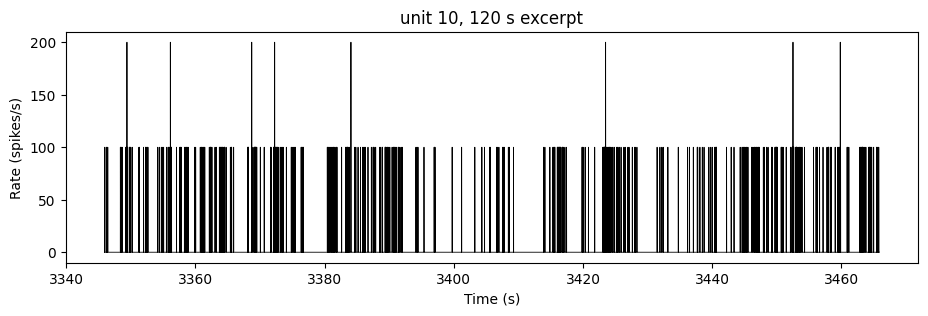

In [26]:
# First the arbitrary choice: pick a cell by its index and plot its trace
# against time. This is effectively a random sample.
example_unit = 10

# A whole session at 10 ms bins is hundreds of thousands of points, so plot a
# 120 s excerpt from the middle of the session rather than everything.
excerpt_start = bin_centers[-1] / 2
in_excerpt = (bin_centers > excerpt_start) & (bin_centers < excerpt_start + 120)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(bin_centers[in_excerpt], spike_rates[in_excerpt, example_unit], 'k', lw=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Rate (spikes/s)')
ax.set_title(f'unit {example_unit}, 120 s excerpt')
plt.show()

In [27]:
# Now choose deliberately. Come up with a selection rule -- for example the
# highest signal-to-noise, or the most stable baseline across the session --
# and say what it is. Plot that cell the same way and compare.

# The rule: the highest mean rate among units whose rate is stable across the
# session. A unit can have a high mean because it fires reliably, or because it
# appeared halfway through and drifted -- comparing block means separates them.
blocks = np.array_split(np.arange(len(bin_centers)), 8)
block_means = np.array([spike_rates[block].mean(axis=0) for block in blocks])
instability = block_means.std(axis=0) / block_means.mean(axis=0)

stable_units = np.flatnonzero(instability < 0.35)
example_unit = int(stable_units[np.argmax(spike_rates[:, stable_units].mean(axis=0))])

print(f'{len(stable_units)} of {spike_rates.shape[1]} units are stable across blocks')
print(f'unit {example_unit}: {spike_rates[:, example_unit].mean():.2f} spikes/s, '
      f'instability {instability[example_unit]:.2f}')

20 of 38 units are stable across blocks
unit 18: 9.43 spikes/s, instability 0.15


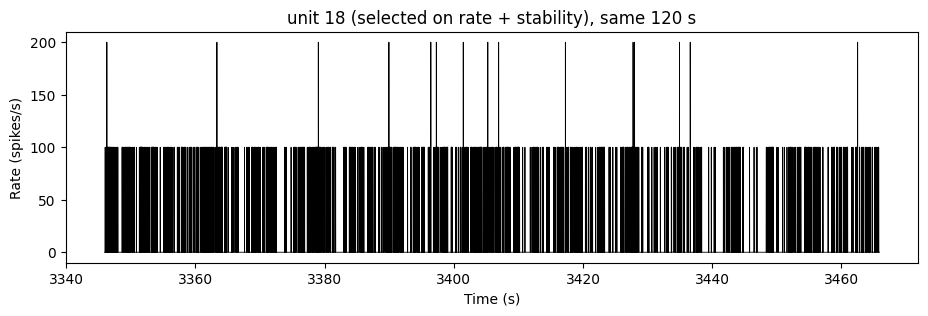

In [28]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(bin_centers[in_excerpt], spike_rates[in_excerpt, example_unit], 'k', lw=0.6)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Rate (spikes/s)')
ax.set_title(f'unit {example_unit} (selected on rate + stability), same 120 s')
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Find any other information needed to reproduce your classmate's plot. 
Is it showing task epochs? Stimulus presentations? 
Is there any behavioral information like reward times or running speed? 
Where do these pieces of data live in this dataset's NWB file structure?

</div>

In [29]:
# Is there an additional timeseries shown? Which container is it in?
# Which tables contain the relevant conditions shown on the plot?

# Behavior is in processing['behavior']; the conditions are in intervals.
running_speed_series = nwb.processing['behavior']['running_speed']
running_speed = np.asarray(running_speed_series.data[:])
running_timestamps = np.asarray(running_speed_series.timestamps[:])
licks = nwb.processing['behavior']['licks']

print('running_speed:', running_speed.shape, '| running_timestamps:', running_timestamps.shape)
print(f'running sampled at {1 / np.median(np.diff(running_timestamps)):.1f} Hz')
print('licks container:', type(licks).__name__)
print('tables in intervals:', list(nwb.intervals.keys()))

running_speed: (388994,) | running_timestamps: (388994,)
running sampled at 60.0 Hz
licks container: DynamicTable
tables in intervals: ['aud_rf_mapping_trials', 'epochs', 'optotagging_trials', 'performance', 'trials', 'vis_rf_mapping_trials']


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 2: Reproduce the figure, and interrogate what it shows</h1>

You have your classmate's figure. You do not have their code, and you may not have a caption either.

<b>Before you write anything, write down what you think the figure shows.</b> One or two sentences,
in your notebook, as a claim someone could disagree with: <i>"activity is higher during X than during
Y"</i>, <i>"the response is larger on this trial type"</i>, <i>"these two signals rise together."</i>

Two reasons this comes first. It commits you to an interpretation before the data can talk you into
one &mdash; and it converts a picture into something you can actually test. A figure cannot be right
or wrong. A claim can.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Write your claim about the figure you picked, in the cell below, before you
write any code.

Be specific enough to be wrong. "There is neural activity" is not a claim; "population activity is
higher in the second half of the session" is.

</div>

_Your claim:_

The figure is a session overview: running speed and population firing rate across the
whole session, with the task epochs shaded behind them. The claim it suggests is

> *"Population firing rate in visual cortex is higher during the receptive-field mapping
> block than during the task block, and the running trace has no gaps."*

Two things make this testable rather than decorative: it names the two blocks being
compared and it asserts a direction. The second half of the claim is about the figure
itself rather than the brain, and it is the part most likely to be wrong -- the two rows
come from different acquisition systems.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Now replicate it</h3>

Get the pieces the figure needs and plot them. 

As you do this, consider the following: 
* What are the decisions that go into making this figure? 
* What pieces of information are present? Are they timeseries, events, epochs? 
* Can you tell how it was filtered, if at all? 
* Are there pieces of data you would have included but they did not?
* How do the decisions made during data visualization influence your understanding of the data?


</div>

In [30]:
# Let's save our activity traces and timestamps with generalizeable names to use in the rest of the notebook

# =====================================================================
# FILL IN FOR YOUR DATASET
# =====================================================================
activity = spike_rates       # (n_timepoints, n_cells)
timestamps = bin_centers     # (n_timepoints,) seconds
events = nwb.intervals['trials'].to_dataframe()   # one row per stimulus presentation / trial

# A second activity representation, if your dataset has one (deconvolved
# events, spike estimates). Set to None if it does not.
# NOTE: this must carry the same QC mask as `activity`.
activity_events = None
second_signal_label = None   # what activity_events holds; None if unused
# =====================================================================

print('activity:', activity.shape, '| events:', events.shape)
print('one activity representation: binned spike rates at', 1000 * bin_width, 'ms')

activity: (669181, 38) | events: (527, 49)
one activity representation: binned spike rates at 10.0 ms


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the same data features that your classmate found in this dataset. 

Do you need to transform the neural activity data in some way?  
Do you need to convert to spike rate or average across the population?  
Which neurons are included? What time period is the plot showing?

Once youve built the plot - What is going on in this session? 
</div>

In [31]:
# Compute whatever your chosen figure shows, or plot the data directly.
# For a population average, the mean across cells at each timepoint.
# For running speed, a single timeseries.
# Are there discrete events? Are all available events included?

population_rate = activity.mean(axis=1)
print('population_rate:', population_rate.shape, '(timepoints,)')

# Epochs are the coarse structure shaded behind the traces. Their labels live in
# the table's `tags` column, and two blocks share the label 'rewards' -- make them
# unique so each gets its own colour and legend entry.
epochs = nwb.intervals['epochs'].to_dataframe()
epochs['label'] = [tags[0] for tags in epochs.tags]
repeat_number = epochs.groupby('label').cumcount()
epochs['label'] = np.where(repeat_number > 0,
                           epochs.label + '_' + (repeat_number + 1).astype(str),
                           epochs.label)
epochs = epochs.set_index('label')[['start_time', 'stop_time']].sort_values('start_time')
epochs['duration_s'] = (epochs.stop_time - epochs.start_time).round(1)
epochs

population_rate: (669181,) (timepoints,)


,start_time,stop_time,duration_s
label,,,
mapping,53.72312,924.469595,870.7
optotagging,935.77911,1053.577970,117.8
spontaneous,1063.25265,1665.774510,602.5
rewards,1680.06988,2282.875250,602.8
task,2293.21714,5933.786150,3640.6
rewards_2,5945.21249,6548.268065,603.1
optotagging_2,6564.79865,6683.364670,118.6


In [32]:
# Here is a helper function from the tutorial in case you need it 

def shade_epoch_blocks(epochs, ax):
    """Shade each epoch on `ax`, one color per epoch label.

    Epochs are the coarse structure of the session -- which stimulus block or
    task phase was running. Shading them behind a trace shows at a glance
    whether a change in activity lines up with a change in what was happening.
    """

    colors = dict(zip(epochs.index, plt.cm.Pastel1.colors))

    for label, row in epochs.iterrows():
        # zorder=0 keeps the shading BEHIND the data; alpha so the trace on top
        # stays readable. label= puts each epoch in the legend once.
        ax.axvspan(row.start_time, row.stop_time, color=colors[label],
                   alpha=0.5, zorder=0, label=label)

35 of 388994 samples set to NaN


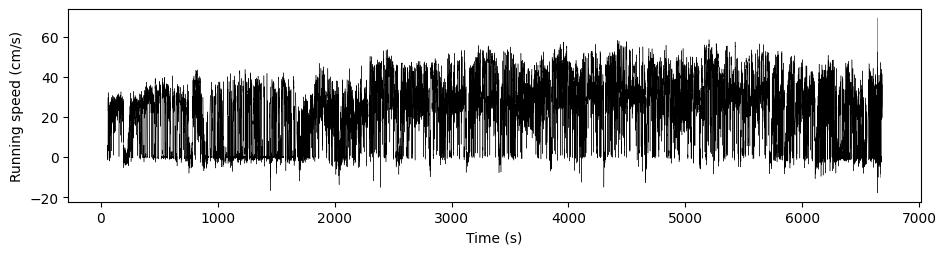

In [33]:
# First lets filter the running trace, since artifacts in the encoder output can cause large spikes in the computed trace
# We know mice cant run faster than ~70cm/s so lets set values larger than that to NaN
# We could use much smarter filtering methods but since this is just for visualization lets do it quick

# Assign to a NEW array rather than writing NaNs into `running_speed` in place.
# In-place edits make the cell order matter: re-running the cell above reloads the
# raw trace, re-running this one clips an already-clipped array, and nothing in
# the notebook tells you which state you are in.
running_speed = np.where((running_speed > 70) | (running_speed < -20), np.nan, running_speed)
print(f'{np.isnan(running_speed).sum()} of {len(running_speed)} samples set to NaN')

# Plot against TIME, not sample index -- the behavior stream has real gaps in it
# (cell above), and an index axis hides them.
plt.figure(figsize=(11, 2.5))
plt.plot(running_timestamps, running_speed, 'k', lw=0.3)
plt.xlabel('Time (s)')
plt.ylabel('Running speed (cm/s)')
plt.show()


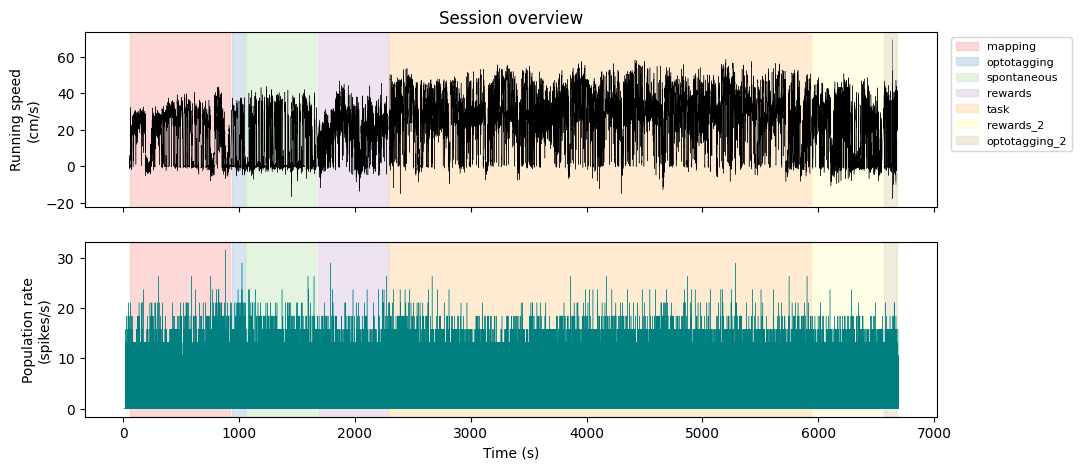

In [34]:
# Plot the figure: one panel per data stream, sharing an x axis, with the
# epochs shaded behind them using the helper above.

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)

axes[0].plot(running_timestamps, running_speed, 'k', lw=0.3)
axes[0].set_ylabel('Running speed\n(cm/s)')
axes[0].set_title('Session overview')

axes[1].plot(timestamps, population_rate, color='teal', lw=0.3)
axes[1].set_ylabel('Population rate\n(spikes/s)')
axes[1].set_xlabel('Time (s)')

for ax in axes:
    shade_epoch_blocks(epochs, ax)

axes[0].legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.show()

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now test the claim you wrote above.

Turn your sentence into a number you can check. If it compares epochs, compute the mean in each one,
alongside how long each epoch lasted, when in the session it happened, and what the animal was doing.
If it compares something else, compute the equivalent.

Before you look: **what would make this comparison unfair?** Write your answer down first, then see
whether the table bears it out.

Is claim as supported, contradicted, or untestable with this data? 

</div>

In [35]:
# For each epoch compute the mean activity, and alongside it the things that
# could confound the comparison: how long the epoch lasted, how many samples
# that is, when in the session it happened, and what the animal was doing.
# Build a DataFrame with one row per epoch.

rows = []
for label, row in epochs.iterrows():
    in_epoch = (timestamps >= row.start_time) & (timestamps < row.stop_time)
    in_epoch_running = (running_timestamps >= row.start_time) & (running_timestamps < row.stop_time)
    rows.append({'epoch': label,
                 'duration_s': round(row.stop_time - row.start_time, 1),
                 'n_bins': in_epoch.sum(),
                 'n_running_samples': in_epoch_running.sum(),
                 'mid_session_min': round((row.start_time + row.stop_time) / 120, 1),
                 # np.nanmean, not .mean(): the clipping above put NaNs into the
                 # trace, and one NaN turns a whole epoch's mean into NaN.
                 'mean_running': round(np.nanmean(running_speed[in_epoch_running]), 2),
                 'mean_rate': round(population_rate[in_epoch].mean(), 3)})

epoch_summary = pd.DataFrame(rows)
epoch_summary

,epoch,duration_s,n_bins,n_running_samples,mid_session_min,mean_running,mean_rate
0,mapping,870.7,87075,51333,8.2,17.74,2.530
1,optotagging,117.8,11780,6377,16.6,11.98,3.518
2,spontaneous,602.5,60252,35997,22.7,12.50,3.271
3,rewards,602.8,60281,35997,33.0,18.99,3.167
4,task,3640.6,364057,216872,68.6,29.88,3.355
5,rewards_2,603.1,60306,35997,104.1,18.92,3.140
6,optotagging_2,118.6,11856,6407,110.4,17.74,3.461


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 3: Align activity to event onsets</h1>

Let's go beyond the figure your classmate made. 

A session overview shows everything at once, which means it shows very little. To see a response
you need to **align** activity to the times when something happened, and look across repeats, not just the average.

This morning's tutorial averaged across presentations. Here we look at what the average hides.

Note that "something happened" need not be a visual stimulus. It might be a sound, an optogenetic pulse, a
reward, a lick, or the start of a trial. Anything with a repeatable onset time works the same way
&mdash; and the rest of this notebook says "event" rather than "stimulus" for that reason.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Identify events of interest. Check the stimulus, trials, intervals, and events tables to see what is available. 

What is happening during this session? What is the subject experiencing? Are there distinct stimuli, trial types, behavior events?

Explore the available conditions and select a specific type of event to examine further. 

</div>

In [36]:
# STIMULUS TABLES -- what was presented. Which container holds these in your
# dataset, and what are the columns?

# The `stimulus` container is empty in this file; what was presented is described
# by the trial tables in `intervals` instead.
print('stimulus container:', list(nwb.stimulus.keys()) if nwb.stimulus else [])
print('intervals        :', list(nwb.intervals.keys()))

stimulus container: []
intervals        : ['aud_rf_mapping_trials', 'epochs', 'optotagging_trials', 'performance', 'trials', 'vis_rf_mapping_trials']


In [37]:
# TRIALS TABLES - when mice perform a task the data can be broken into distinct trials
# Does your dataset have one? How does it differ from the stimulus table?

task_trials = nwb.intervals['trials'].to_dataframe()
print('task trials:', task_trials.shape)
print(list(task_trials.columns))
task_trials.head()

task trials: (527, 49)
['start_time', 'stop_time', 'quiescent_start_time', 'quiescent_stop_time', 'stim_start_time', 'stim_stop_time', 'response_window_start_time', 'response_window_stop_time', 'task_control_response_time', 'response_time', 'reward_time', 'post_response_window_start_time', 'post_response_window_stop_time', 'stim_name', 'grating_phase', 'block_index', 'rewarded_modality', 'trial_index', 'trial_index_in_block', 'repeat_index', 'is_response', 'is_correct', 'is_incorrect', 'is_hit', 'is_false_alarm', 'is_correct_reject', 'is_miss', 'is_go', 'is_nogo', 'is_rewarded', 'is_noncontingent_reward', 'is_contingent_reward', 'is_reward_scheduled', 'is_instruction', 'is_aud_stim', 'is_vis_stim', 'is_catch', 'is_target', 'is_aud_target', 'is_vis_target', 'is_nontarget', 'is_aud_nontarget', 'is_vis_nontarget', 'is_vis_rewarded', 'is_aud_rewarded', 'is_block_switch', 'is_repeat', 'is_opto', 'is_task_control_correct']


,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,grating_phase,...,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2296.85936,2302.36397,2296.85936,2298.32728,2298.388130,2298.88855,2298.44403,2299.36147,2299.06127,2299.04571,2299.07796,2299.38897,2302.391490,vis1,0.0,...,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
1,2302.71427,2308.21889,2302.71427,2304.18219,2304.243050,2304.74347,2304.29940,2305.21642,NaN,NaN,2305.21642,2305.24389,2308.246400,vis1,0.5,...,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
2,2309.23641,2314.75773,2309.23641,2310.70430,2310.765190,2311.26561,2310.82106,2311.73855,NaN,NaN,2311.73855,2311.76602,2314.785230,vis1,0.5,...,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
3,2316.07551,2321.59680,2316.07551,2317.54340,2317.604260,2318.10468,2317.66019,2318.57760,2318.27731,2318.27728,2318.29399,2318.60509,2321.624305,vis1,0.5,...,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False
4,2322.53087,2328.05218,2322.53087,2323.99883,2324.059675,2324.56010,2324.11558,2325.03298,2324.54932,2324.54079,2324.56593,2325.06051,2328.079717,vis1,0.0,...,False,True,False,True,False,True,False,False,False,True,False,False,False,False,False


In [38]:
# EVENTS - discrete events that happened in the session
# Note not all datasets have an events table within the events container

# No events container here. Licks and rewards are in processing['behavior'], and
# reward times also appear as a column on the trials table.
print('events container:', list(nwb.events.keys()) if nwb.events else [])
print('behavior        :', list(nwb.processing['behavior'].data_interfaces))
print('trials with a reward time:', int(task_trials.reward_time.notna().sum()))

events container: []
behavior        : ['facemap_front_camera', 'facemap_side_camera', 'running_speed', 'dlc_eye_camera', 'eye_tracking', 'licks', 'lp_front_camera', 'lp_side_camera', 'quiescent_interval_violations', 'rewards']
trials with a reward time: 145


In [39]:
# INTERVALS -- time periods within a session, could be a stimulus or a trial type or a stimulus block
# Note not all datasets have an intervals table within the intervals container

rf_mapping_trials = nwb.intervals['vis_rf_mapping_trials'].to_dataframe()
print('vis_rf_mapping_trials:', rf_mapping_trials.shape)
print(list(rf_mapping_trials.columns))
rf_mapping_trials.head()

vis_rf_mapping_trials: (1224, 11)
['start_time', 'stop_time', 'stim_start_time', 'stim_stop_time', 'trial_index', 'is_small_field_grating', 'grating_orientation', 'grating_x', 'grating_y', 'is_full_field_flash', 'flash_contrast']


,start_time,stop_time,stim_start_time,stim_stop_time,trial_index,is_small_field_grating,grating_orientation,grating_x,grating_y,is_full_field_flash,flash_contrast
id,,,,,,,,,,,
0,53.70054,54.19597,53.723120,53.973330,0,True,45.0,-159.744551,146.240918,False,NaN
1,54.76312,55.26353,54.790670,55.040885,2,True,180.0,159.744551,438.722753,False,NaN
2,55.28021,55.78063,55.307775,55.557990,3,True,90.0,479.233652,-438.722753,False,NaN
3,55.79730,56.29775,55.824870,56.075080,4,True,225.0,-479.233652,146.240918,False,NaN
4,56.31441,56.81487,56.341980,56.592180,5,True,90.0,-798.722753,146.240918,False,NaN


In [40]:
# Choose which table holds your events of interest, and save it to a variable
# called `events`. Set `condition_column` to the column whose value defines a
# condition, and `onset_column` to the column holding the event time.
# Check that the table you picked actually has the condition column you want --
# some datasets have a general-purpose intervals table that mixes several kinds
# of row together and lacks the per-presentation columns.

events = task_trials
condition_column = 'stim_name'
onset_column = 'stim_start_time'

# The RF mapping table would give more repeats, but its stimulus also moves
# around the screen, so trials sharing an orientation are not repeats of the same
# thing. The task table's stim_name is a clean condition label.
print('events:', events.shape)
print(events[[condition_column, onset_column]].head())

events: (527, 49)
   stim_name  stim_start_time
id                           
0       vis1      2298.388130
1       vis1      2304.243050
2       vis1      2310.765190
3       vis1      2317.604260
4       vis1      2324.059675


In [41]:
# How many times was each chosen condition presented?
# Are there different variations on a given event type?
# How does your selection of event types and conditions influence the amount of data you have?

print(events[condition_column].value_counts().to_string())
print()

# Two auditory stimuli, two visual, plus catch trials with no stimulus at all.
# Which of the four is the rewarded target changes between blocks, so the same
# stim_name means a different task demand in different parts of the session.
print('blocks         :', events.block_index.nunique())
print(events.rewarded_modality.value_counts().to_string())

stim_name
sound1    130
vis1      129
vis2      116
sound2    112
catch      40

blocks         : 6
rewarded_modality
vis    267
aud    260


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Are all of these events the same kind of event?</h3>

An event table usually contains rows that are **not equivalent trials**. Depending on the dataset
that might be first versus repeated presentations, rewarded versus unrewarded trials, different
stimulus families, trials the animal responded to versus ignored, blocks recorded before and after
a manipulation, or blank and omitted entries that are not events at all.

This matters before you align anything, for two reasons:

- **Response magnitude can differ several-fold between trial types.** Averaging them together dilutes
  the response toward whichever type is most numerous &mdash; which is often the weakest one.
- **Trial types differ in what else is happening.** Reward, licking, and arousal ride along with some
  trial types and not others, so a difference you attribute to the stimulus may not be about the
  stimulus.

Find the columns in your table that distinguish trial types, and count them.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Pick two conditions from your table and pull out the onset times of each. How many
repetitions are there of each one?

**Name the variables for what they hold.** By the end of this notebook you will have a dozen arrays
of aligned windows, masks, and subsets of subsets, and nothing in the code will remind you which is
which. `change_onset_times` and `repeat_onset_times` tell you their contents every time you read
them; `event_times_a` and `event_times_b` mean you have to scroll back to find out. The same goes
for indices: a cell index derived from one activity matrix no longer points at the same neuron once
you subset the cells, so re-derive it rather than carrying it forward.

</div>

In [42]:
# Pull out the onset times of your two chosen conditions. Name each variable for
# the condition it holds, not 'a' and 'b' -- you will still be using these names
# several sections from now.

vis1_onset_times = events.loc[events[condition_column] == 'vis1', onset_column].values
sound1_onset_times = events.loc[events[condition_column] == 'sound1', onset_column].values

print('vis1_onset_times  :', len(vis1_onset_times), 'presentations')
print('sound1_onset_times:', len(sound1_onset_times), 'presentations')

vis1_onset_times  : 129 presentations
sound1_onset_times: 130 presentations


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Align the population average to
each event separately, then plot both on the same axes.

Write down your prediction first: do you expect a difference, and how large?

</div>

_Your prediction:_

Prediction: the visual stimulus will drive these units and the auditory one will not,
because every unit here was selected for sitting in a VIS-prefixed structure. I expect a
clear increase within about 100 ms of visual onset and something close to flat for
`sound1`, with any auditory difference smaller than the visual one by several fold.

Committing to "several fold" rather than "a difference" is what makes the prediction
checkable. It could still be wrong in an informative way: licking and reward follow the
rewarded target whichever modality it is, and movement-related activity reaches visual
cortex.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

To compare them we need to cut a window of data around each onset. Same
`align_to_event_times` helper as this morning's tutorial.

</div>

In [43]:
# Here is the helper function from today's tutorial, with comments added so you can follow the logic

def align_to_event_times(data, timestamps, event_times, pre=0.5, post=1.5):
    """Cut a window of data around each event time.

    data        : array with time along the first axis
    timestamps  : time of each row of data, in seconds
    event_times : times to align to, in seconds
    pre, post   : seconds before and after each event

    Returns (aligned_windows, window_time_axis) where the time axis is in
    seconds relative to the event, and there is one window per usable_cells event.
    """
    # Sampling interval. Median, not mean: one gap in the recording would
    # inflate a mean and silently shrink every window.
    dt = np.median(np.diff(timestamps))

    # Convert the requested seconds into a number of samples. int() truncates,
    # so a window that is not a whole number of samples comes out slightly
    # short -- check this if you need exact window edges.
    n_pre, n_post = int(pre / dt), int(post / dt)

    aligned_windows = []
    for event_time in event_times:
        # Index of the first sample AT OR AFTER the event. side='left' returns
        # the insertion point, so timestamps[i] >= event_time always.
        #
        # Do NOT round to the nearest sample: that pulls roughly half the
        # trials one sample EARLIER than the event, which smears the onset and
        # can make a real response look like it starts before the stimulus.
        # Landing just after is honest -- the bias is one-directional and at
        # most one sample.
        i = np.searchsorted(timestamps, event_time, side='left')

        # Skip events too close to either end of the recording to fill a whole
        # window. This drops trials SILENTLY, so compare
        # aligned_windows.shape[0] against len(event_times) afterwards.
        if i - n_pre >= 0 and i + n_post <= len(timestamps):
            # Slice is n_pre + n_post samples long. Index n_pre within the
            # window is the first sample at/after the event, i.e. t = 0.
            aligned_windows.append(data[i - n_pre:i + n_post])

    # Time axis in seconds relative to the event. Starts at -n_pre*dt, which
    # can be slightly later than -pre because of the truncation above.
    window_time_axis = np.arange(-n_pre, n_post) * dt
    return np.array(aligned_windows), window_time_axis

In [44]:
# Feed your population average timeseries and your event times into the helper function, once for each condition
# Consider what window around each event you want to look at and adjust the input parameters to the function accordingly
# How often does your event repeat? A post window longer than that runs into the next one.

# Trials run about 5.5 s each, so a 1 s post window stays inside one trial.
pre, post = 0.5, 1.0

aligned_vis1, window_time_axis = align_to_event_times(population_rate, timestamps,
                                                     vis1_onset_times, pre=pre, post=post)
aligned_sound1, _ = align_to_event_times(population_rate, timestamps,
                                         sound1_onset_times, pre=pre, post=post)

print('aligned_vis1  :', aligned_vis1.shape, '(n_events, n_bins)')
print('aligned_sound1:', aligned_sound1.shape, '(n_events, n_bins)')

aligned_vis1  : (129, 150) (n_events, n_bins)
aligned_sound1: (130, 150) (n_events, n_bins)


In [45]:
# What does the output look like?
# Compare the number of windows you got back against the number of onsets you asked for. Are they the same?

print('vis1  : asked for', len(vis1_onset_times), '| got back', aligned_vis1.shape[0])
print('sound1: asked for', len(sound1_onset_times), '| got back', aligned_sound1.shape[0])
print(f'window spans {window_time_axis[0]:+.2f} to {window_time_axis[-1]:+.2f} s '
      f'in {len(window_time_axis)} bins')

vis1  : asked for 129 | got back 129
sound1: asked for 130 | got back 130
window spans -0.50 to +0.99 s in 150 bins


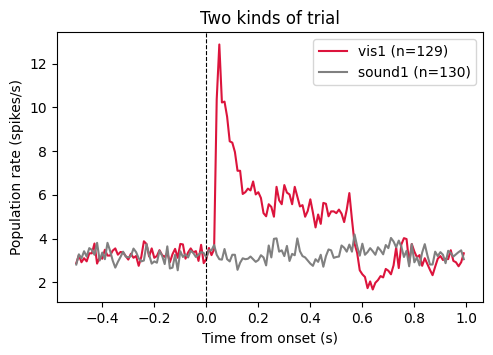

In [46]:
# Take the mean across the aligned windows for each condition and plot them on the same axis. Label them accordingly.
# Make sure you understand the units of the x and y axes and label them as well.
# What exactly is on the y axis -- a rate, a fractional change, something else?

# y: spikes per second, averaged over units and then over trials. It is a real
# rate because the bin counts were divided by the bin width.
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(window_time_axis, aligned_vis1.mean(axis=0), color='crimson',
        label=f'vis1 (n={len(aligned_vis1)})')
ax.plot(window_time_axis, aligned_sound1.mean(axis=0), color='gray',
        label=f'sound1 (n={len(aligned_sound1)})')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Population rate (spikes/s)')
ax.set_title('Two kinds of trial')
ax.legend()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

What are some decisions you can make in how you process and plot the data that can affect your interpretation? 

Should you subtract the pre-event baseline? Or are you interested in the baseline activity level? 

What happens if you bin the data with a different window? 

</div>

In [47]:
# A note on baseline subtraction: exclude the sample immediately before event onset from your baseline window.
# With binned or sampled data that sample can straddle the event,  including
# it puts part of the response into the baseline and shrinks what you
# measure. e.g. `window_time_axis < -bin_width` rather than `< 0`.

is_baseline = window_time_axis < -bin_width

print(f'bin width {1000 * bin_width:.0f} ms')
print('baseline bins with `< -bin_width`:', is_baseline.sum())
print('baseline bins with `< 0`         :', (window_time_axis < 0).sum())

bin width 10 ms
baseline bins with `< -bin_width`: 49
baseline bins with `< 0`         : 50


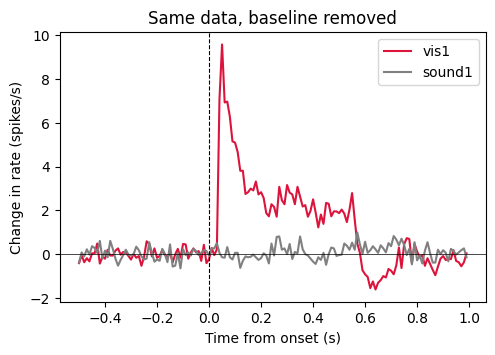

In [48]:
# Try plotting the same two conditions with the pre-event baseline subtracted, and
# compare against the version above. Subtracting the baseline asks "how much did
# the stimulus change activity"; keeping it asks "how active was the population
# around this event". Which question do you want to answer?

mean_vis1 = aligned_vis1.mean(axis=0)
mean_sound1 = aligned_sound1.mean(axis=0)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(window_time_axis, mean_vis1 - mean_vis1[is_baseline].mean(),
        color='crimson', label='vis1')
ax.plot(window_time_axis, mean_sound1 - mean_sound1[is_baseline].mean(),
        color='gray', label='sound1')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Change in rate (spikes/s)')
ax.set_title('Same data, baseline removed')
ax.legend()
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Are you looking at the right signal?</b>

Most datasets ship more than one representation of the same activity. &Delta;F/F carries the
indicator's rise and decay, so a brief response is smeared forward by hundreds of milliseconds.
Deconvolved events estimate when the cell actually fired, so they are temporally tighter but mostly
exact zeros &mdash; which makes single-trial estimates much noisier even though the trial average
looks cleaner. Spike times are discrete, and you choose the bin width yourself.

None is more correct; it depends on your question. A question about response <i>latency</i> is badly
served by &Delta;F/F, and one needing a reliable per-trial number is badly served by a sparse
signal. Pick one, say why, and if you have time run the analysis twice and compare.

</div>

In [49]:
# If your dataset has more than one type of signal, recreate the plot above for each. Plot them side by side.
# What are the differences? How would it affect your interpretation?

# This dataset has one signal. Spike times are not a "representation" of anything
# else, and there is no deconvolved or continuous version to compare against --
# saying so is the correct answer to this prompt, not a gap.
# What IS a choice here is the bin width, and the next cell compares three of them.
print('activity representations available:', 1)
print('second_signal_label:', second_signal_label)

activity representations available: 1
second_signal_label: None


In [50]:
# Even if your dataset only has one signal (spike times), your choice of binning can affect the result
# Try recreating the spike times array with different bin widths and plot the average event aligned response with both versions side by side
# For continuous data, averaging adjacent samples asks the same question: how
# much does temporal resolution change the answer?

# Rebin the SAME spike times three ways, from the per-unit spike lists.
population_rate_by_bin_width = {}
for width in [0.010, 0.050, 0.100]:
    edges = np.arange(0, bin_edges[-1] + width, width)
    rates = np.zeros((len(edges) - 1, len(spike_lists)))
    for unit_index, unit_spike_times in enumerate(spike_lists):
        counts, _ = np.histogram(unit_spike_times, bins=edges)
        rates[:, unit_index] = counts / width
    population_rate_by_bin_width[width] = (rates.mean(axis=1), edges[:-1] + width / 2)

print({f'{1000 * w:.0f} ms': len(rate) for w, (rate, _) in population_rate_by_bin_width.items()})

{'10 ms': 669181, '50 ms': 133837, '100 ms': 66919}


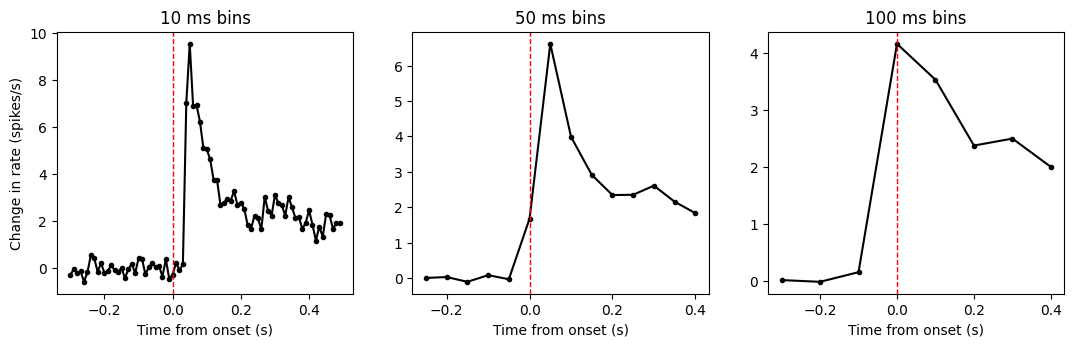

In [51]:
# Align each version to the same onsets and plot them side by side.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for ax, width in zip(axes, [0.010, 0.050, 0.100]):
    rate, centers = population_rate_by_bin_width[width]
    windows, window_axis = align_to_event_times(rate, centers, vis1_onset_times,
                                               pre=0.3, post=0.5)
    baseline = windows[:, window_axis < -width].mean(axis=1, keepdims=True)
    ax.plot(window_axis, (windows - baseline).mean(axis=0), 'k', marker='o', ms=3)
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.set_xlabel('Time from onset (s)')
    ax.set_title(f'{1000 * width:.0f} ms bins')

axes[0].set_ylabel('Change in rate (spikes/s)')
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>What does the average hide?</h3>

Everything so far has been an average &mdash; over cells, then over trials. Averaging is what makes a
small response visible, but it also throws away the two things that make population data
interesting.

<b>Variability across cells.</b> Neurons are highly heterogeneous, and understanding that diversity
is a central goal of neuroscience. A population average of a hundred cells can look like a modest
response whether every cell responded modestly or five cells responded strongly and ninety-five did
nothing at all.

<b>Variability across trials.</b> Present the identical stimulus fifty times and no neuron gives the
same answer twice. Some of that is measurement noise, but much of it is real: arousal, running,
recent stimulus history, and whatever else the brain was doing on that particular trial.

Both are invisible in a mean trace, so the next two plots put them back &mdash; every trial of one
cell, then every cell of one condition. Part 4 then turns each kind of variability into a number.

</div>

In [52]:
# The peak is at the same time in all three panels, so the response latency is not
# an artifact of the binning. What changes is the shape and the noise: at 10 ms the
# onset transient is resolved but each point rests on a handful of spikes, at
# 100 ms the transient is averaged into the sustained response and disappears.
# 50 ms is the compromise between the two -- though note the rest of this notebook
# stays at the 10 ms `bin_width` chosen in Part 1, which is the finer end of that
# trade-off and is why the single-trial plots below look as sparse as they do.


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose an example cell to look at, and say how you chose it.

Papers often show example cells without disclosing how they were selected. Taking the first cell in
the table is effectively a random sample; selecting the most responsive cell is a different choice
that changes your impression of the data. Either is defensible &mdash; state which you did.

</div>

In [53]:
# Choose an example cell - it can be random, based on activity level, or based on some metric
# Write down the rationale for your selection criterion
# Pick the trial type and condition you will use, and check it has enough
# repetitions for a readable raster.

chosen_condition = 'vis1'
onset_times = vis1_onset_times

print('condition:', chosen_condition, '| presentations:', len(onset_times))
print('rows in the raster:', len(onset_times))

condition: vis1 | presentations: 129
rows in the raster: 129


In [54]:
# Now apply your selection rule to find the example cell. If you select on
# responsiveness, note the choice is deliberately biased -- it guarantees the
# example looks responsive and tells you nothing about the typical cell.
# Print your cell's score alongside the median across cells.

# The rule: the most stimulus-modulated unit -- mean evoked response divided by
# its standard deviation across trials.
windows, t_window = align_to_event_times(activity, timestamps, onset_times, pre=0.3, post=0.5)
evoked = (windows[:, t_window >= 0].mean(axis=1)
          - windows[:, t_window < -bin_width].mean(axis=1))

# GUARD THE DIVISION. A unit with no spikes anywhere in these windows -- a unit
# the probe lost partway through the session, say -- gives evoked = 0 on every
# trial, so mean/std is 0/0 = NaN. np.argmax treats NaN as the largest value and
# would hand back exactly that dead unit, which then looks like a blank raster
# and a PSTH flat at zero further down. Score only the units that actually fired
# in this window, and use the NaN-aware argmax.
fired_in_window = windows.sum(axis=(0, 1)) > 0
modulation = np.full(windows.shape[2], np.nan)
modulation[fired_in_window] = (evoked[:, fired_in_window].mean(axis=0)
                               / evoked[:, fired_in_window].std(axis=0))
modulation[~np.isfinite(modulation)] = np.nan     # x/0 from any other degenerate unit
example_unit = int(np.nanargmax(modulation))

print('windows:', windows.shape, '(n_trials, n_bins, n_units)')
print(f'silent in every {chosen_condition} window: {(~fired_in_window).sum()} unit(s)',
      np.flatnonzero(~fired_in_window), '-- excluded from the selection')
print(f'most modulated unit: {example_unit} (score {modulation[example_unit]:.3f})')
print(f'median across scored units: {np.nanmedian(modulation):.3f} -- the example is not typical')


windows: (129, 80, 38) (n_trials, n_bins, n_units)
silent in every vis1 window: 1 unit(s) [30] -- excluded from the selection
most modulated unit: 27 (score 3.105)
median across scored units: 0.413 -- the example is not typical


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Raster vs PSTH</h3>

The event-aligned average is also called a PSTH (peri-stimulus time histogram); a plot showing every
individual trial is called a raster. Plot them together so you can see what the average discards.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** For one of your two conditions, plot the raster and the PSTH side by side. 

Using the same cell you've been working with, show the response for every trial as a heatmap (rows are trials, columns are timepoints). This is a raster.

Then plot the PSTH as the average across trials with the across trial variance as errorbars. 
Compute the standard error of the mean (standard deviation across trials divided by the square root of number of trials) 
and plot errorbars using matplotlib's fill_between()

</div>

In [55]:
# Plot the raster and the PSTH side by side: every trial as a heatmap, and
# the trial average with a measure of variability acros trials.

aligned_windows, t = align_to_event_times(activity[:, example_unit], timestamps,
                                         onset_times, pre=pre, post=post)
mean = aligned_windows.mean(axis=0)
standard_error = aligned_windows.std(axis=0) / np.sqrt(len(aligned_windows))

print('aligned_windows:', aligned_windows.shape, '(n_trials, n_bins)')

aligned_windows: (129, 150) (n_trials, n_bins)


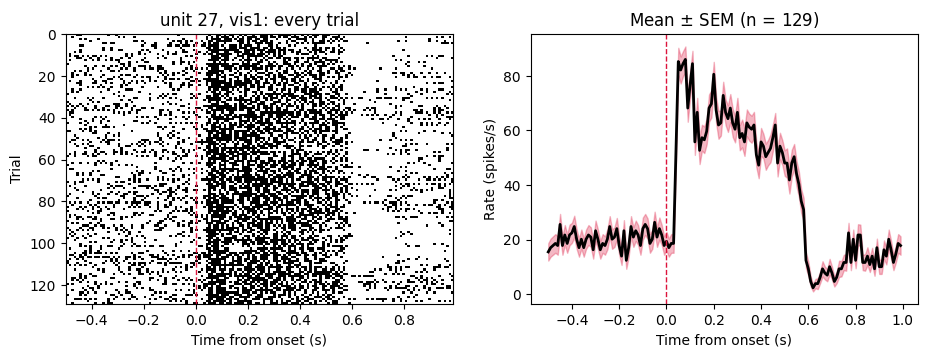

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# SHOW THE RASTER AS SPIKE / NO SPIKE. At a 10 ms bin width a unit fires at most
# one spike per bin and ~97% of the array is zero, so a percentile-based colour
# limit -- np.percentile(aligned_windows, 98) -- comes out at 0 for all but the
# highest-rate units. vmin == vmax == 0 renders a uniformly blank image, which
# reads as "this unit did not respond" rather than "the colour scale collapsed".
# interpolation='nearest' matters too: the default antialiasing averages isolated
# single-pixel spikes away when the array is downsampled to screen resolution.
axes[0].imshow(aligned_windows > 0, aspect='auto', cmap='Greys', vmin=0, vmax=1,
               interpolation='nearest',
               extent=[t[0], t[-1], len(aligned_windows), 0])
axes[0].axvline(0, color='crimson', ls='--', lw=1)
axes[0].set_ylabel('Trial')
axes[0].set_title(f'unit {example_unit}, {chosen_condition}: every trial')

axes[1].plot(t, mean, 'k', lw=2)
axes[1].fill_between(t, mean - standard_error, mean + standard_error,
                     color='crimson', alpha=0.3)
axes[1].axvline(0, color='crimson', ls='--', lw=1)
axes[1].set_ylabel('Rate (spikes/s)')
axes[1].set_title(f'Mean $\\pm$ SEM (n = {len(aligned_windows)})')

for ax in axes:
    ax.set_xlabel('Time from onset (s)')
plt.show()


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>PSTH across cells</h3>

We have now seen average differences across conditions on average, variability across trials for one cell - how about variability across cells for one condition?

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Now compute the average response for every cell and plot the result as a heatmap, sorted by
response magnitude. How many cells respond?

</div>

In [57]:
# Build an array of (n_cells, n_timepoints) where the value for each cell is the condition mean
# Plot the response array as a heatmap, sorted by response magnitude.

condition_mean_traces = []
for unit in range(activity.shape[1]):
    windows_unit, t = align_to_event_times(activity[:, unit], timestamps,
                                          onset_times, pre=pre, post=post)
    condition_mean_traces.append(windows_unit.mean(axis=0))

condition_mean_traces = np.array(condition_mean_traces)
print('condition_mean_traces:', condition_mean_traces.shape, '(n_units, n_bins)')

condition_mean_traces: (38, 150) (n_units, n_bins)


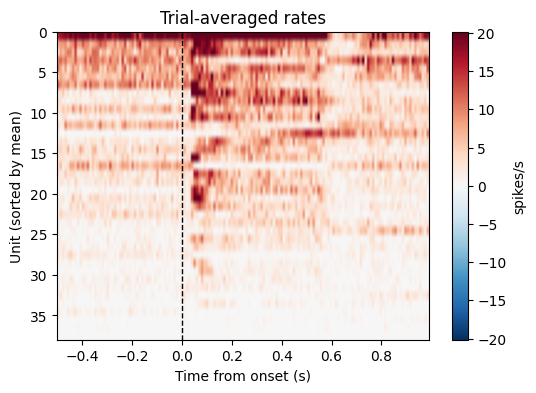

In [58]:
order = np.argsort(condition_mean_traces.mean(axis=1))[::-1]
vmax = np.percentile(np.abs(condition_mean_traces), 98)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(condition_mean_traces[order], aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax, extent=[t[0], t[-1], len(condition_mean_traces), 0])
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel('Unit (sorted by mean)')
ax.set_title('Trial-averaged rates')
plt.colorbar(im, ax=ax, label='spikes/s')
plt.show()

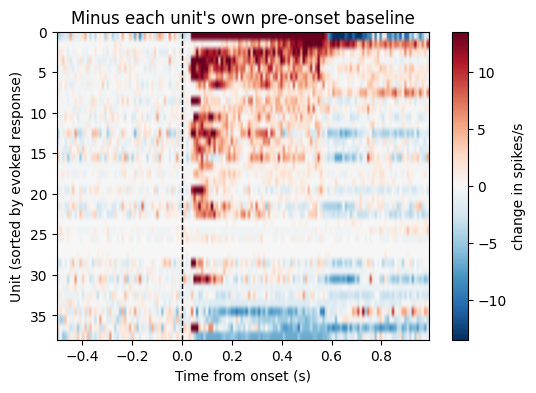

In [59]:
# Plot it again with each cell's own pre-onset baseline subtracted, and compare the two versions.
# How does baseline subtraction influence the interpretation?
# Was this the appropriate thing to do given the stimulus or event conditions you are using?

baseline = condition_mean_traces[:, t < -bin_width].mean(axis=1, keepdims=True)
change_in_rate = condition_mean_traces - baseline

order = np.argsort(change_in_rate[:, t >= 0].mean(axis=1))[::-1]
vmax = np.percentile(np.abs(change_in_rate), 98)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(change_in_rate[order], aspect='auto', cmap='RdBu_r',
               vmin=-vmax, vmax=vmax, extent=[t[0], t[-1], len(change_in_rate), 0])
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Time from onset (s)')
ax.set_ylabel("Unit (sorted by evoked response)")
ax.set_title("Minus each unit's own pre-onset baseline")
plt.colorbar(im, ax=ax, label='change in spikes/s')
plt.show()

In [60]:
# Compare the two panels. What is the sorting in the first panel actually
# ordering the cells by? How many cells increase after onset, and how many
# decrease?

evoked_per_unit = change_in_rate[:, t >= 0].mean(axis=1)
print('units that increase:', (evoked_per_unit > 0).sum(), '/', len(evoked_per_unit))
print('units that decrease:', (evoked_per_unit < 0).sum())
print('units with exactly zero change:', (evoked_per_unit == 0).sum(),
      '-- no spikes at all in this window, which is why the two counts above\n         need not sum to the number of units')

# The first panel sorts by each unit's overall firing rate, which spans an order
# of magnitude here and swamps a response of a few spikes/s. Only after
# subtracting each unit's own baseline does the sort order mean "responsive".

units that increase: 26 / 38
units that decrease: 11
units with exactly zero change: 1 -- no spikes at all in this window, which is why the two counts above
         need not sum to the number of units


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Part 4: Signal and noise correlations</h1>

<h3>What are signal and noise correlations, and what can they tell us?</h3>

A single neuron's average response to a stimulus is the most reported measurement in systems
neuroscience, and it is also one of the least informative things you can compute from a population
recording. Neurons do not act alone. Two cells recorded at the same time can look identical on
average and still carry different information, depending on whether they fluctuate together or
independently from trial to trial.

Correlations are how that structure gets measured, and there are two distinct kinds. They are
computed from the same data, and they answer different questions.

<b>Do two cells like the same things?</b> If both respond strongly to vertical gratings and weakly
to horizontal ones, they are tuned alike. Cells that are tuned alike often sit near each other or
belong to the same functional class, so this is a statement about functional organization.

<b>Do two cells wobble together?</b> Present the identical stimulus fifty times and no neuron gives
the same answer twice. If two cells are above their own average on the same trials, some shared
influence is moving them together.

The second one is what limits how much the population can encode. If every cell wobbles
independently, averaging across cells cancels the wobble out and the population estimate gets better
the more cells you add. If they all wobble together, averaging does not help, and a thousand neurons
carry barely more information than one.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The math</h3>

Both are the same operation &mdash; a Pearson correlation &mdash; applied to different inputs. The
Pearson correlation between two variables $x$ and $y$ is

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
              {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} $$

In words: **center** each variable by subtracting its mean, **multiply** the centered values
pointwise and sum, then **normalize** by each variable's spread so the result falls between -1 and
+1. `np.corrcoef` does all three steps for you.

Two consequences that matter for everything below:

- $r$ says nothing about response **size**, only whether two things move together.
- $r$ is computed over a set of paired observations, and **how many observations you have determines
  how noisy $r$ is** &mdash; but the value itself gives you no clue how many there were.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<b>Demonstration: what does a given value of $r$ look like?</b>

Nothing below uses real data &mdash; these are <b>simulated</b> pairs of random numbers, generated
with a known correlation, so you can calibrate your eye before you trust a number computed from a
recording. Just run the cell.

</div>

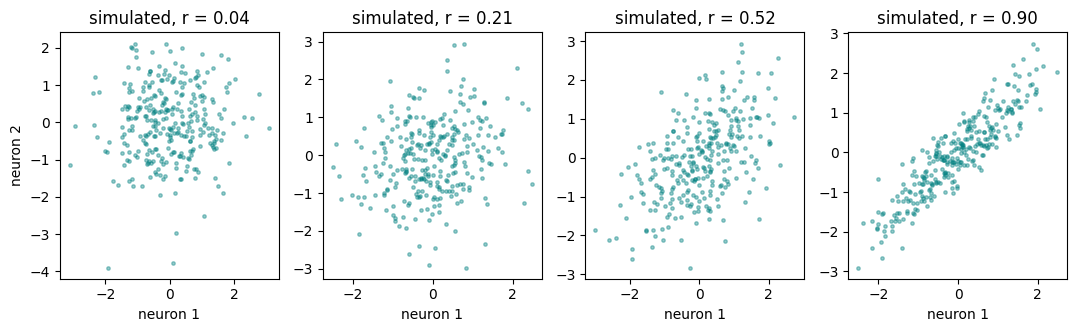

In [61]:
# SIMULATED DATA -- not from the recording. Each panel is a pair of random
# variables generated with a known correlation.
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, target_r in zip(axes, [0.0, 0.2, 0.5, 0.9]):
    simulated_x = rng.normal(size=300)
    simulated_y = target_r * simulated_x + np.sqrt(1 - target_r ** 2) * rng.normal(size=300)
    ax.scatter(simulated_x, simulated_y, s=6, alpha=0.4, color='teal')
    ax.set_title(f'simulated, r = {np.corrcoef(simulated_x, simulated_y)[0, 1]:.2f}')
    ax.set_xlabel('neuron 1')

axes[0].set_ylabel('neuron 2')
plt.show()

In [62]:
# Mean pairwise correlations in cortex are typically 0.01-0.1 -- weaker than the
# leftmost panel. Real and consequential at the population level, but no single
# pair of neurons looks impressive.


<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Correlate two neurons.

Take the full activity traces of two cells, compute the correlation between them with
`np.corrcoef`, and plot one against the other with the r value in the title.

Compare what you see against the simulated panels above.

</div>

In [63]:
# Take the full activity traces of two cells and compute the correlation
# between them with np.corrcoef. Plot one against the other, with the
# correlation in the title.

first_unit = activity[:, example_unit]
second_unit = activity[:, (example_unit + 1) % activity.shape[1]]
r_value = np.corrcoef(first_unit, second_unit)[0, 1]
print(f'at {1000 * bin_width:.0f} ms bins: n = {len(first_unit)} bins, r = {r_value:.3f}')

# A 10 ms bin holds one spike or none, so each rate is 0 or 1/bin_width and the
# scatter can only land on a few lattice points. Pooling bins into a coarser
# window gives counts that actually vary, which is what makes the cloud readable.
bins_per_window = int(round(0.5 / bin_width))          # 500 ms windows
n_keep = (len(first_unit) // bins_per_window) * bins_per_window
coarse_first = first_unit[:n_keep].reshape(-1, bins_per_window).mean(axis=1)
coarse_second = second_unit[:n_keep].reshape(-1, bins_per_window).mean(axis=1)
coarse_r = np.corrcoef(coarse_first, coarse_second)[0, 1]
print(f'at 500 ms bins: n = {len(coarse_first)} bins, r = {coarse_r:.3f}')

at 10 ms bins: n = 669181 bins, r = 0.035
at 500 ms bins: n = 13383 bins, r = 0.209


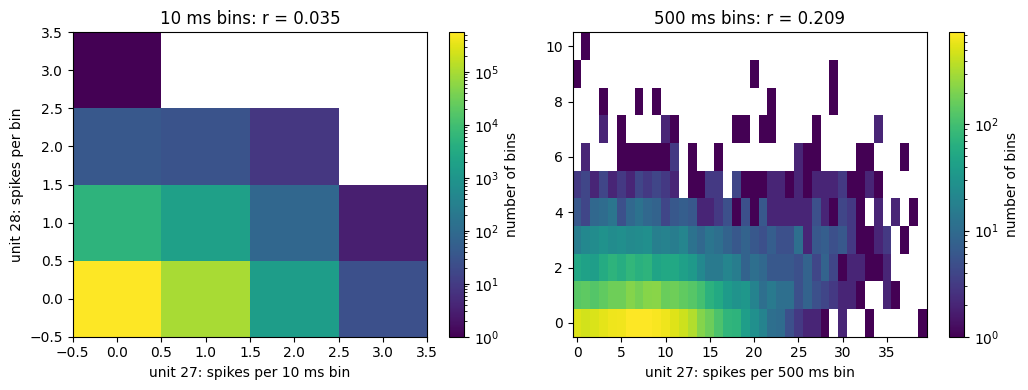

fraction of 10 ms bins where NEITHER unit fired: 0.838


In [64]:
# PLOT SPIKE COUNTS, NOT RATES, and bin the histogram on the data's own lattice --
# one histogram bin per integer spike count.
#
# Two things were wrong with a scatter of rates here. First, 669,181 points at
# alpha=0.15 saturate every lattice point to fully opaque, so the panel showed
# which values are POSSIBLE and nothing about how often each occurs. Second, a
# rate axis reading "0, 100, 200 spikes/s" invites you to read a continuous axis
# that has been mangled, when the honest statement is "0, 1, 2 spikes".
#
# Note this changes NOTHING statistical. Pearson's r is invariant under
# multiplication by a positive constant and rate = count / bin_width is exactly
# that, so the r values in the titles are identical either way. Only the axis
# changes -- and with it, whether the axis can be misread.
def count_edges(*arrays):
    """One histogram bin per integer spike count, each centred on its value."""
    highest = max(int(a.max()) for a in arrays)
    return np.arange(-0.5, highest + 1.5)

fine_a = (first_unit * bin_width).round().astype(int)
fine_b = (second_unit * bin_width).round().astype(int)
coarse_a = (coarse_first * 0.5).round().astype(int)         # 500 ms windows
coarse_b = (coarse_second * 0.5).round().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))

# The panels keep their own limits on purpose: how many values a count can take
# IS the difference between the two timescales, so do not force a shared axis.
for ax, (x, y, r, width) in zip(axes, [(fine_a, fine_b, r_value, bin_width),
                                       (coarse_a, coarse_b, coarse_r, 0.5)]):
    _, _, _, im = ax.hist2d(x, y, bins=[count_edges(x), count_edges(y)],
                            cmap='viridis', norm=LogNorm())
    fig.colorbar(im, ax=ax, label='number of bins')
    ax.set_xlabel(f'unit {example_unit}: spikes per {1000 * width:.0f} ms bin')
    ax.set_title(f'{1000 * width:.0f} ms bins: r = {r:.3f}')

axes[0].set_ylabel(f'unit {(example_unit + 1) % activity.shape[1]}: spikes per bin')
plt.tight_layout()
plt.show()

# The number the eye cannot recover from a scatter: how much of the data sits in
# the single most common cell.
print(f'fraction of {1000 * bin_width:.0f} ms bins where NEITHER unit fired: '
      f'{((fine_a == 0) & (fine_b == 0)).mean():.3f}')


In [65]:
# NOTHING was binned for the plot on the left beyond the binning you chose: the
# lattice IS the data. A 10 ms bin holds 0 or 1 spikes and nothing between, so
# the pair of counts can only sit in a few rows and columns, most of them stacked
# at (0, 0). Widen the bin and the counts per bin rise, the lattice spacing falls
# relative to the spread, and the cloud starts to look like the simulated panels.
#
# Reading the left panel as a RATE would be generous in a second way too: with
# most bins empty, r there is driven by how often the two units happen to fire in
# the same short window -- a coincidence measure more than a rate correlation.
#
# The two r values are the real lesson: a spike-train correlation is a statement
# about a TIMESCALE, not just about a pair of neurons. Coincidences within 10 ms
# and co-fluctuation over half a second are different quantities, and which one
# you report is set by a parameter you chose several cells ago. Say the bin width
# whenever you report a correlation on binned spikes.


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>The two kinds of correlations, and the one array they both come from</h3>

- <b>Signal correlation.</b> Do two cells respond similarly <i>across conditions</i>? Take each
  cell's average response to each condition &mdash; its tuning curve &mdash; and correlate the two
  curves. This is a statement about shared tuning, and so about functional organization.
- <b>Noise correlation.</b> When the <i>same</i> condition repeats, do the two cells fluctuate
  together around their own averages? Remove each condition's mean and correlate what is left. This
  is a statement about shared variability &mdash; <b>not</b> about connectivity, for the reasons
  above.

<b>Both come from the same array.</b> One number per cell, per trial, per condition:

<pre>
responses[condition, trial, cell]
</pre>

Every trial contributes one number for each cell &mdash; its mean activity in a window after onset,
minus its own baseline just before. Once you have that array, the two correlations are two different
ways of collapsing it.

<table>
<tr><td><b>Signal</b></td><td>average over <i>trials</i> &rarr; a tuning curve per cell &rarr;
correlate cells across <i>conditions</i></td></tr>
<tr><td><b>Noise</b></td><td>subtract each condition's mean &rarr; correlate cells across
<i>trials</i>, within one condition &rarr; average those matrices over conditions</td></tr>
</table>

Note which axis each one correlates over, because it sets how many observations you get. With 8
conditions and 400 trials per condition, a signal correlation rests on <b>8</b> paired numbers and a
noise correlation on <b>400</b>. Both render as equally convincing heatmaps.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 1: decide what conditions to compare</h3>

Everything below rests on one choice: which trials count as repeats of the same thing. Get this
wrong and every correlation downstream measures something you did not intend, with no error message.

Not every event in your table is comparable to every other. Two trials can share the same stimulus
label and still differ in what else was happening &mdash; one followed a reward and the other did
not, the animal was running through one and sitting still through the other, one was its first
exposure and one its five hundredth. Those differences do not disappear when you average; they
become part of what you are calling the response.

Pick the subset that makes a fair comparison, pick the column whose value defines the condition, and
write down why. Both choices belong in your methods.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose your condition column and your trial subset.

Count how many trials there are of each condition, and check whether they are balanced &mdash; the
least common condition is what limits you. Then say in a sentence which trials you are keeping and
why.

</div>

In [66]:
# How many trials of each condition, and how balanced are they? The least
# common condition is what limits you.

counts = events[condition_column].value_counts()
print(counts.to_string())
print(f'\nleast common: {counts.min()} | most common: {counts.max()} '
      f'| balance {counts.min() / counts.max():.2f}')

stim_name
sound1    130
vis1      129
vis2      116
sound2    112
catch      40

least common: 40 | most common: 130 | balance 0.31


In [67]:
# Restrict to the trials you consider comparable, and keep the onset times and
# the condition labels side by side -- they must stay the same length as each
# other from here on. Say why you kept the trials you kept.

# Keep every trial that presented a stimulus. Catch trials have no stimulus at
# all, so they are not a fifth condition. Restricting to visual trials alone would
# leave two conditions and two observations per signal correlation.
comparable_trials = events[events[condition_column].isin(['vis1', 'vis2', 'sound1', 'sound2'])]

all_onset_times = comparable_trials[onset_column].values
labels = comparable_trials[condition_column].values

print(len(events), 'trials ->', len(comparable_trials), 'comparable trials')
print(pd.Series(labels).value_counts().to_string())

527 trials -> 487 comparable trials
sound1    130
vis1      129
vis2      116
sound2    112


In [68]:
# What this does NOT control for: which modality is rewarded switches between
# blocks, so two trials with the same stim_name can differ in what the animal had
# to do and whether a lick followed. That difference does not disappear when you
# average -- it becomes part of what we are calling the response.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 2: build the response array</h3>

One number per cell per trial: mean activity in a <b>response window</b> after onset, minus mean
activity in a <b>baseline window</b> just before it.

The baseline subtraction matters. Without it each trial's "response" includes wherever the cell
happened to be sitting beforehand, and those resting levels drift together across the whole
population as the recording bleaches and the animal's arousal changes. That shared drift becomes a
large positive noise correlation with nothing to do with the stimulus.

The function below does the whole thing. Read it before you run it &mdash; it is eight lines of real
work, and every one of them is a decision you could have made differently. The two window choices
stay <i>outside</i> the function, because they are yours to set and they propagate into every number
in the rest of this notebook.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Choose your windows, then build the array.

1. Set the two windows and check how many samples each one holds. A "baseline" of one sample is not
   an average.
2. Do one cell by hand, and look at the per-trial numbers, so you know what the function is
   producing before you trust it on 60 cells.
3. Run the function and check the shape it hands back.

</div>

In [69]:
# 1. Choose your response window and your baseline window. These are the
#    decisions -- everything downstream inherits them. Print how many SAMPLES
#    each holds: a "baseline" of one sample is not an average.

# Spikes are fast: the Part 3 plot showed the transient within ~150 ms of onset.
# A calcium window of half a second would average most of it away.
response_window = (0.0, 0.2)
baseline_window = (-0.25, 0.0)

print(f'bin width      : {1000 * bin_width:.0f} ms')
print('response bins  :', int((response_window[1] - response_window[0]) / bin_width))
print('baseline bins  :', int((baseline_window[1] - baseline_window[0]) / bin_width),
      '(one fewer after dropping the bin straddling onset)')

bin width      : 10 ms
response bins  : 20
baseline bins  : 25 (one fewer after dropping the bin straddling onset)


In [70]:
# 2. Do one cell by hand, so you can see what the function will be doing for
#    every cell. Align, take the mean of each window, subtract, and look at the
#    per-trial numbers and their spread.

windows, window_time_axis = align_to_event_times(
    activity[:, example_unit], timestamps, all_onset_times,
    pre=-baseline_window[0], post=response_window[1])

is_response = window_time_axis >= 0
is_baseline = window_time_axis < -bin_width     # excludes the bin straddling onset
evoked = windows[:, is_response].mean(axis=1) - windows[:, is_baseline].mean(axis=1)

print('windows:', windows.shape, '(n_trials, n_bins)')
print('first 5 trials:', np.round(evoked[:5], 2))
print(f'mean {evoked.mean():+.3f}, sd {evoked.std():.3f} spikes/s across all trials')

windows: (487, 45) (n_trials, n_bins)
first 5 trials: [35.83 40.83 51.67 31.67 19.17]
mean +20.460, sd 26.669 spikes/s across all trials


In [71]:
def build_response_array(activity, timestamps, onset_times, labels,
                         response_window, baseline_window):
    """One response value per condition, per trial, per cell.

    Returns
    -------
    responses : (n_conditions, n_trials, n_cells)
        Mean activity in the response window minus mean activity in the baseline
        window, for every cell on every trial, grouped by condition.
    conditions : (n_conditions,)
        The condition label of each slice along the first axis.

    Both correlations in this notebook are computed from this one array -- signal
    by averaging over trials, noise by removing each condition's mean. Which
    means every choice made below shows up in every number you report.
    """
    # ONE CELL AT A TIME. align_to_event_times expects a 1-D trace, and looping
    # keeps it obvious that nothing is mixed across cells. It also silently drops
    # any trial whose window would run off the end of the recording -- which is
    # why we re-derive the label list from the returned length further down.
    per_cell = []
    for cell in range(activity.shape[1]):
        windows, window_time_axis = align_to_event_times(
            activity[:, cell], timestamps, onset_times,
            pre=-baseline_window[0], post=response_window[1])

        # RESPONSE minus BASELINE, per trial. Subtracting each trial's OWN
        # baseline is what removes slow drift in that cell across the session; a
        # single session-wide baseline would leave the drift in the response.
        bin_width = np.median(np.diff(window_time_axis))
        is_response = window_time_axis >= 0
        is_baseline = window_time_axis < -bin_width   # drop the sample straddling onset

        per_cell.append(windows[:, is_response].mean(axis=1)
                        - windows[:, is_baseline].mean(axis=1))

    # The loop built one row per CELL; everything downstream wants trials first.
    trial_by_cell = np.array(per_cell).T
    trial_labels = np.asarray(labels)[:len(trial_by_cell)]

    # GROUP BY CONDITION. Stacking into a rectangular array needs the same trial
    # count in every condition, so each one is truncated to the length of the
    # least common. Those dropped trials are real data you are choosing not to
    # use -- if your conditions are badly unbalanced, most of your data is here.
    conditions = np.unique(trial_labels)
    n_trials = min((trial_labels == c).sum() for c in conditions)

    responses = np.stack([trial_by_cell[trial_labels == c][:n_trials]
                          for c in conditions])
    return responses, conditions

In [72]:
# 3. Run the function. The shape is the thing to check: conditions, trials,
#    cells. Then build the index of unique cell pairs used by every summary below.

responses, conditions = build_response_array(
    activity, timestamps, all_onset_times, labels,
    response_window, baseline_window)

# DROP UNITS WITH NO TRIAL-TO-TRIAL VARIANCE, ONCE, HERE. A unit that fired no
# spikes in any window of some condition has zero variance across that
# condition's trials, and np.corrcoef divides by that standard deviation: the
# result is a NaN row and column that then propagates into every mean, every
# percentile, every colour limit and every reliability score below -- silently,
# because a NaN inside a heatmap just looks like a pale square.
# Fixing it at the source beats patching each plot with nan-safe functions.
varies = (responses.std(axis=1) > 0).all(axis=0)
print(f'dropping {(~varies).sum()} unit(s) with no trial-to-trial variance in at least '
      f'one condition:', np.flatnonzero(~varies))
responses = responses[:, :, varies]

# NOTE: unit indices from here on refer to this REDUCED set, not to the columns
# of `activity`. `np.flatnonzero(varies)[i]` maps back if you need it -- this is
# the same "re-derive indices, never carry them" trap flagged in Part 3.

# Every unit pair exactly once, leaving out the diagonal (which is 1 by
# construction). Used by every correlation summary below.
pairs = np.triu_indices(responses.shape[2], k=1)

print('responses:', responses.shape, '(n_conditions, n_trials, n_units)')
print('conditions:', list(conditions), '| unique unit pairs:', len(pairs[0]))


dropping 1 unit(s) with no trial-to-trial variance in at least one condition: [30]
responses: (4, 112, 37) (n_conditions, n_trials, n_units)
conditions: ['sound1', 'sound2', 'vis1', 'vis2'] | unique unit pairs: 666


In [73]:
# What did the truncation cost? Compare the trials kept against the trials
# available for each condition.

available = pd.Series(labels).value_counts().sort_index()
print(f'kept {responses.shape[1]} trials per condition, out of:')
print(available.to_string())
print(f'\ntotal used: {responses.shape[0] * responses.shape[1]} of {len(labels)} trials')

kept 112 trials per condition, out of:
sound1    130
sound2    112
vis1      129
vis2      116

total used: 448 of 487 trials


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 3: signal correlations</h3>

Two steps, in this order:

1. **Average over trials** &mdash; `responses.mean(axis=1)` gives `(condition, cell)`. Each column is
   one cell's tuning curve.
2. **Correlate the cells** across conditions.

Plot the tuning curves before you correlate them. A correlation matrix computed from flat,
featureless curves looks exactly as convincing as one computed from sharply tuned cells.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the tuning curves, plot them, then correlate them.

`np.corrcoef` correlates **rows**, and cells are the columns of your tuning array &mdash; so
transpose. Check the output shape against your number of cells.

</div>

tuning_curves: (4, 37) (n_conditions, n_units)


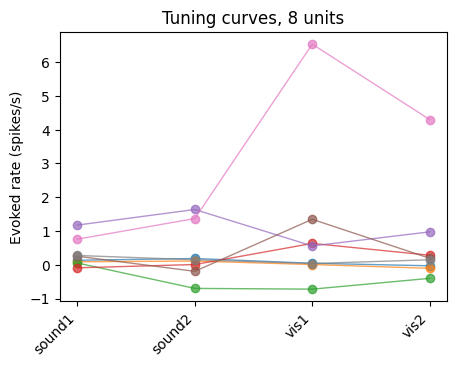

In [74]:
# Average over trials -> one tuning curve per cell. Plot a few of them before
# you correlate anything: are the curves shaped, or flat?

tuning_curves = responses.mean(axis=1)
print('tuning_curves:', tuning_curves.shape, '(n_conditions, n_units)')

fig, ax = plt.subplots(figsize=(5, 3.5))
for unit in range(8):
    ax.plot(tuning_curves[:, unit], marker='o', lw=1, alpha=0.7)
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=45, ha='right')
ax.set_ylabel('Evoked rate (spikes/s)')
ax.set_title('Tuning curves, 8 units')
plt.show()

In [75]:
# Correlate the cells. .T because np.corrcoef correlates ROWS and cells are columns.
# Check the output shape against your number of cells, then plot the matrix.

signal_correlations = np.corrcoef(tuning_curves.T)

print('signal_correlations:', signal_correlations.shape, '| n_units:', responses.shape[2])
print('observations behind each value:', responses.shape[0], 'conditions')

signal_correlations: (37, 37) | n_units: 37
observations behind each value: 4 conditions


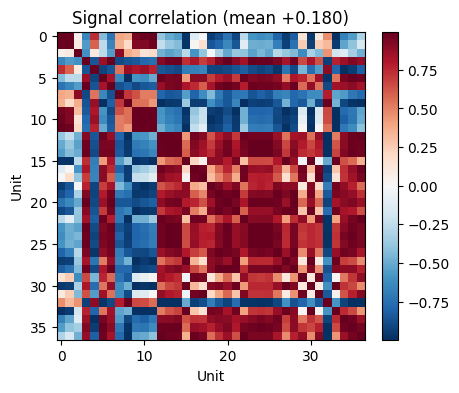

In [76]:
# Plot the signal correlation matrix. Set the colour limit from the 98th
# percentile of the off-diagonal values -- the diagonal is 1 by construction
# and would otherwise set the scale for everything else.

# nanpercentile / nanmean throughout: one NaN pair would otherwise make vmax
# itself NaN, and an image drawn with vmin = vmax = NaN comes out blank.
vmax = np.nanpercentile(np.abs(signal_correlations[pairs]), 98)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(signal_correlations, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Unit')
ax.set_ylabel('Unit')
ax.set_title(f'Signal correlation (mean {np.nanmean(signal_correlations[pairs]):+.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 4: noise correlations</h3>

Same array, collapsed the other way:

1. **Remove each condition's mean** from its own trials. What is left is everything the condition
   does not explain.
2. **Correlate the cells across trials, within one condition** &mdash; this gives one cell &times;
   cell matrix per condition.
3. **Average those matrices** over conditions.

Two things to be careful about. Subtract each condition's <b>own</b> mean, not the grand mean:
subtracting the grand mean leaves the differences between conditions in the residuals, which makes
your "noise" correlation partly a signal correlation. And note that the correlation runs over
<b>trials</b> &mdash; a single trial gives one number per cell, which is not enough to correlate
anything.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Compute the residuals, then the noise correlations.

A **residual** is what is left of a trial once you subtract the average of the trials it belongs
with. If one image evokes a mean response of 0.05 and this trial gave 0.07, the residual is +0.02
&mdash; this trial ran hotter than the condition explains. Residuals average to zero within each
condition by construction, so all the condition structure is gone and what remains is the
trial-to-trial wobble.

Check that the residuals do average to about zero within every condition. If they do not, you
subtracted the wrong mean.

</div>

In [77]:
# Remove each condition's own mean to get the residuals. keepdims keeps the
# shape broadcastable. Check the residuals average to ~0 within every condition.

residuals = responses - responses.mean(axis=1, keepdims=True)

print('residuals:', residuals.shape)
print('mean within each condition:', np.round(residuals.mean(axis=(1, 2)), 12))

residuals: (4, 112, 37)
mean within each condition: [ 0.  0.  0. -0.]


In [78]:
# One correlation matrix per condition, correlating cells across that
# condition's trials. Then average the matrices, and plot the result.

per_condition = [np.corrcoef(residuals[i].T) for i in range(len(conditions))]
noise_correlations = np.mean(per_condition, axis=0)

print('noise_correlations:', noise_correlations.shape)
print('observations behind each value:', responses.shape[1], 'trials per condition')

noise_correlations: (37, 37)
observations behind each value: 112 trials per condition


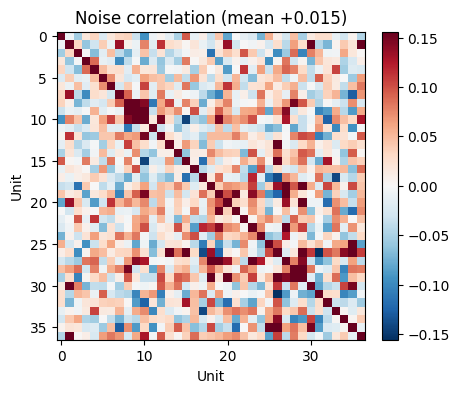

In [79]:
vmax = np.nanpercentile(np.abs(noise_correlations[pairs]), 98)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(noise_correlations, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Unit')
ax.set_ylabel('Unit')
ax.set_title(f'Noise correlation (mean {np.nanmean(noise_correlations[pairs]):+.3f})')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h3>Step 5: put them side by side</h3>

Do cells that like the same stimuli also fluctuate together? Plot one against the other, a point per
cell pair.

</div>

<div style="background: #DFF0D8; border-radius: 3px; padding: 10px;">

**Exercise:** Plot the signal and noise correlation heatmaps next to each other, then plot the relationship between them as a scatterplot. 
The x-axis should show the signal correlation for each pair of neurons and the y-axis should show the noise correlation for each pair. 

How strong is the relationship? What does it mean? 
</div>

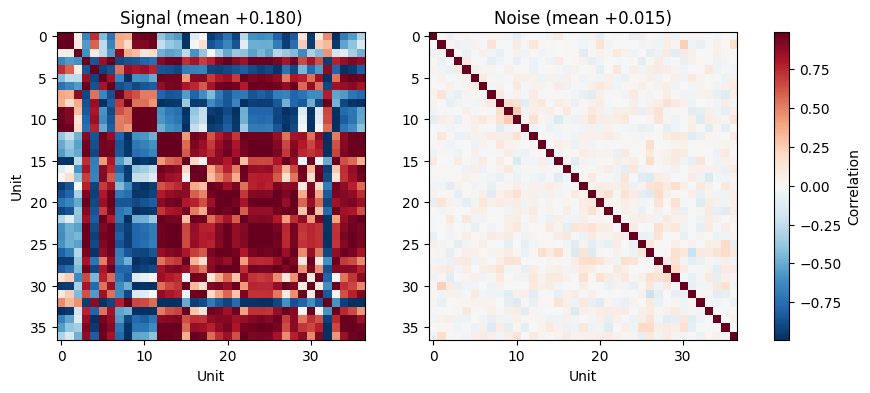

In [80]:
# Plot both matrices side by side on the SAME colour scale, so the comparison
# is fair. Pool the off-diagonal values of both to set one shared limit.

vmax = np.nanpercentile(np.abs(np.concatenate([signal_correlations[pairs],
                                               noise_correlations[pairs]])), 98)

# ONE Normalize OBJECT, SHARED BY BOTH IMAGES. Passing vmin/vmax to each imshow
# separately looks equivalent and is not, in one specific failure: if vmax comes
# out NaN, the panel that is NOT handed to plt.colorbar keeps the NaN limits and
# renders completely blank, while the colorbar call quietly autoscales the panel
# it was given from that panel's own data. You end up with one empty axis and one
# that looks fine on a scale nobody chose -- which is precisely what this cell
# exists to rule out. A shared norm fails loudly instead.
norm = plt.Normalize(-vmax, vmax)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, matrix, name in zip(axes, [signal_correlations, noise_correlations],
                            ['Signal', 'Noise']):
    im = ax.imshow(matrix, cmap='RdBu_r', norm=norm)
    ax.set_xlabel('Unit')
    ax.set_title(f'{name} (mean {np.nanmean(matrix[pairs]):+.3f})')

axes[0].set_ylabel('Unit')
plt.colorbar(im, ax=axes, fraction=0.023, label='Correlation')
plt.show()


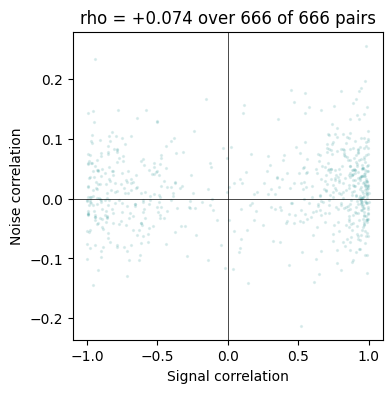

In [81]:
# One point per unit pair: its signal correlation against its noise correlation.
# nan_policy='omit' so a single degenerate pair cannot turn the whole
# statistic into NaN. It should be a no-op after the drop in step 2 --
# if the printed pair count falls short, something upstream is still NaN.
rho = stats.spearmanr(signal_correlations[pairs], noise_correlations[pairs],
                      nan_policy='omit').statistic
usable_pairs = np.isfinite(signal_correlations[pairs]) & np.isfinite(noise_correlations[pairs])

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(signal_correlations[pairs], noise_correlations[pairs],
           s=2, alpha=0.1, color='teal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Signal correlation')
ax.set_ylabel('Noise correlation')
ax.set_title(f'rho = {rho:+.3f} over {usable_pairs.sum()} of {len(pairs[0])} pairs')
plt.show()

In [82]:
# Compare the two matrices' TEXTURE, not their numbers. Signal correlations here
# rest on four conditions per pair, noise correlations on every trial of each --
# and both render as equally convincing heatmaps.
#
# A positive relationship in the scatter is the classic cortical result: units that
# prefer the same stimuli also share their trial-to-trial fluctuations. It matters
# for coding, because shared variability aligned with the signal does not average
# away as you add neurons.
#
# It is NOT evidence that these units are connected. Shared upstream input, arousal
# and running, licking that follows the rewarded modality, and drift in the
# recording all produce the same pattern. This is functional organization, and
# perturbation is what would test coupling.
#
# ONE MORE THING TO READ OFF THE SCATTER. The signal correlations pile up against
# -1 and +1 rather than spreading out. That is not strong shared tuning -- it is
# what a correlation over FOUR paired numbers looks like. With n = 4 the possible
# values of r are close to quantized and |r| > 0.9 is common by chance, so the
# x axis here is far coarser than it appears. If you want signal correlations
# with any resolution, you need more conditions: the RF mapping table, or
# splitting each stimulus by block, would both give you more than four.


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Is this result trustworthy?</h1>

Every number so far is a point estimate with no error bar. The single most useful check: **would you
get the same answer with half the data?**

Split the trials in half at random, compute the correlations on each half separately, and correlate
the two halves' answers. Split **within each condition** so both halves see every condition.

Three outcomes, and all three are informative:

- **One high, one low** &mdash; trust the high one, and say why the other is not trustworthy.
- **Both high** &mdash; you have enough data for both; proceed.
- **Both near zero** &mdash; report that. It usually means the condition variable you chose does not
  organize these neurons' responses, however well-balanced it looked. That is a real result about
  your dataset, and it is a better README than a matrix you cannot defend.

The cell below is worked for you. Run it on your own `responses` array.

</div>

In [83]:
# Make sure your response array is saved to a variable called "response" so the following code will run

print('responses:', responses.shape, '| conditions:', list(conditions))
print('unit pairs:', len(pairs[0]))

responses: (4, 112, 37) | conditions: ['sound1', 'sound2', 'vis1', 'vis2']
unit pairs: 666


In [84]:
# Split the trials of each condition into two halves. Both halves must see
# every condition, so split WITHIN each condition rather than across all trials.
rng = np.random.default_rng(0)
n_half = responses.shape[1] // 2

shuffled = rng.permutation(responses.shape[1])
half_a = responses[:, shuffled[:n_half]]
half_b = responses[:, shuffled[n_half:2 * n_half]]

print('half_a:', half_a.shape, '| half_b:', half_b.shape)

half_a: (4, 56, 37) | half_b: (4, 56, 37)


In [85]:
# Compute the signal correlations from each half, then ask how well the two
# halves agree over cell pairs (scipy.stats.spearmanr).
signal_a = np.corrcoef(half_a.mean(axis=1).T)
signal_b = np.corrcoef(half_b.mean(axis=1).T)

# nan_policy='omit': a 56-trial half can leave a sparse unit with no variance
# even when it had some across all 112 trials, so NaNs can reappear here.
signal_reliability = stats.spearmanr(signal_a[pairs], signal_b[pairs],
                                     nan_policy='omit').statistic
print(f'signal correlation reliability: {signal_reliability:.3f}')
print(f'  from {responses.shape[0]} conditions per half')

signal correlation reliability: 0.678
  from 4 conditions per half


In [86]:
# Same for noise correlations.
noise_a = np.mean([np.corrcoef((half_a[i] - half_a[i].mean(axis=0)).T)
                   for i in range(len(conditions))], axis=0)
noise_b = np.mean([np.corrcoef((half_b[i] - half_b[i].mean(axis=0)).T)
                   for i in range(len(conditions))], axis=0)

noise_reliability = stats.spearmanr(noise_a[pairs], noise_b[pairs],
                                    nan_policy='omit').statistic
print(f'noise correlation reliability: {noise_reliability:.3f}')
print(f'  from {n_half} trials per condition per half')

noise correlation reliability: 0.261
  from 56 trials per condition per half


/opt/conda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [87]:
# HOW TO READ THE TWO NUMBERS ABOVE.
#
# Each reliability correlates two independent halves of your own data, so it
# answers "would I get this answer again?", not "is this answer big?". A result
# that does not reproduce across halves of the SAME recording will not reproduce
# in another animal.
#
# Compare each reliability against the observation count printed beside it.
# Signal correlations are computed over conditions, noise correlations over
# trials, and there are usually far more trials than conditions -- so when the
# two reliabilities differ, that gap is normally the explanation. Correlating
# two short vectors is noisy no matter how many trials went into each entry.
#
# Nothing in the heatmaps told you this. Two matrices can look equally
# structured while one is a stable feature of the population and the other is
# what noise looks like in colour.
#
# both high         -> report both, with the reliability alongside them.
# one high, one low -> report the reliable one; say the other is under-sampled,
#                      and what it would take to measure it.
# both near zero    -> report that too. Either you need more data, or your
#                      condition variable does not organize these responses.


---

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<h1>Summary</h1>

<h3>The process</h3>

1. **Find out what is in the file** before analyzing it &mdash; and check that the dataset supports
   your question. Sometimes the answer is no.
2. **Plot the data after each transformation.** Single trials before averages; tuning curves before
   correlations.
3. **Name every decision.** Event subset, condition column, response window, baseline. Each is a
   fork, and each belongs in your methods.
4. **Try to break your own result.** Split the data in half and see if the answer survives.
5. **Let the dataset answer back.** If the check says your result is noise, or the dataset has no
   variable that supports your question, that is the finding. Report it rather than reaching for the
   analysis you planned to run.

<h3>Traps this notebook demonstrated</h3>

| trap | how you catch it |
| --- | --- |
| A result from few observations looks like one from many | split-half reliability |
| Analyzing units that should have been dropped | select on quality columns, and say so |
| Epoch comparisons confounded with time and behavior | check durations, order, behavior |
| An example cell chosen to look good | state your selection rule |
| Data looks absent but is stored elsewhere | look in every container first |
| An index from an earlier cell after reshaping the data | re-derive indices, never carry them |

<h3>Why this matters</h3>

You can generate an analysis faster than you can validate one. The only defense is to know your data
well enough that a wrong answer looks wrong to **you** &mdash; because it will not look wrong to the
code, and it will not look wrong on the plot.

</div>